# Automated VWAP V2 Backtest Runner

This notebook is the V2 automated backtest runner for the VWAP Probability Band Engine project.

V2 starts as a direct copy of V1 so the baseline can be verified before adding new trend-health logic.

It tests one defined automated strategy version on historical OHLC CSV data.

The notebook is separate from the research notebook and separate from the visual/discretionary MT5 overlay.

This notebook does not connect to MT5 and does not place live trades.

## Strategy Version

**Version:** Automated VWAP V2

V2 keeps the V1 automated entry structure but adds an adaptive trend-health filter before a raw green reclaim/rejection setup becomes a valid signal.

The entry structure remains:

- upper-green reclaim for longs
- lower-green rejection for shorts
- entry at next bar open
- fixed SL / TP / BE
- same daily risk controls as V1

The new V2 filter requires:

- price accepted on the correct side of VWAP
- correct red band shifting in the trade direction
- last red shift strong enough relative to recent average red shift
- red bands spreading or not compressing
- opposite red band moving away
- trend not dead by 5 bad green closes

This commit activates the V2 trend-health filter. It does not add second-close entries, failed-auction setups, orange entries, or reversal logic.

## 1. Project Setup

This section imports the required libraries, detects the project root, and defines the main project folders used by the notebook.

In [1]:
from pathlib import Path
from pprint import pprint
import json
import sys

import numpy as np
import pandas as pd


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start_path: Path | None = None) -> Path:
    """
    Find the project root by walking upward until the expected repository
    structure is found.

    This works whether the project was cloned with Git or downloaded as a ZIP,
    and whether the notebook is run from the project root or from notebooks/.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        has_project_structure = (
            (path / "src").is_dir()
            and (path / "data").is_dir()
            and (path / "notebooks").is_dir()
        )

        has_repo_marker = (
            (path / ".git").exists()
            or (path / "README.md").exists()
            or (path / "requirements.txt").exists()
        )

        if has_project_structure and has_repo_marker:
            return path

    raise FileNotFoundError(
        "Could not find the project root. Make sure this notebook is being run "
        "from inside the VWAP-probability-band-engine project folder."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
HISTORICAL_DATA_DIR = DATA_DIR / "historical"
SRC_DIR = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUT_DIR = ARTIFACTS_DIR / "automated_vwap_v2"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Historical data folder:", HISTORICAL_DATA_DIR)
print("Source folder:", SRC_DIR)
print("Output folder:", OUTPUT_DIR)

Current working directory: c:\GitHub Projects\VWAP-probability-band-engine\notebooks
Detected project root: C:\GitHub Projects\VWAP-probability-band-engine
Historical data folder: C:\GitHub Projects\VWAP-probability-band-engine\data\historical
Source folder: C:\GitHub Projects\VWAP-probability-band-engine\src
Output folder: C:\GitHub Projects\VWAP-probability-band-engine\artifacts\automated_vwap_v2


## 2. Editable Strategy Configuration

This is the main control panel for the V2 backtest.

Most basic V2 experiments should be possible by changing this cell only.

The parameters are kept in one place so V2 can be tested and adjusted without changing the rest of the notebook.

In [2]:
CONFIG = {
    # ------------------------------------------------------------------
    # Dataset
    # ------------------------------------------------------------------
    # Main dataset used by the normal single-run backtest
    "csv_file": "US100_cash_M1_NY_session_30d.csv",
    "dataset_name": "US100_cash_M1_NY_session_30d",

    # Datasets used by the final comparison table
    "comparison_datasets": [
        {
            "csv_file": "US100_cash_M1_NY_session_30d.csv",
            "dataset_name": "US100_cash_M1_NY_session_30d",
        },
        {
            "csv_file": "US100_cash_M1_NY_session_1y.csv",
            "dataset_name": "US100_cash_M1_NY_session_1y",
        },
    ],

    # ------------------------------------------------------------------
    # Strategy identity
    # ------------------------------------------------------------------
    "strategy_version": "automated_vwap_v2",
    "strategy_description": "V2 continuation VWAP green reclaim/rejection with adaptive red-shift, band-spread, opposite-expansion, and trend-not-dead filters",

    # ------------------------------------------------------------------
    # Session handling
    # ------------------------------------------------------------------
    "session_timezone": "Europe/London",
    "no_new_trades_after": "19:00",

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    "allow_longs": True,
    "allow_shorts": True,

    # ------------------------------------------------------------------
    # Strategy filters
    # ------------------------------------------------------------------
    "strategy_family": "continuation_only",
    "strategy_filter": "v2_adaptive_trend_health",
    "red_shift_filter_choice": "adaptive_relative_red_shift",

    # ------------------------------------------------------------------
    # Entry logic
    # ------------------------------------------------------------------
    "entry_timing": "next_bar_open",

    # ------------------------------------------------------------------
    # Fixed Nasdaq point trade levels
    # ------------------------------------------------------------------
    "sl_points": 29.0,
    "tp_points": 58.0,
    "be_trigger_points": 29.0,

    # ------------------------------------------------------------------
    # Risk controls
    # ------------------------------------------------------------------
    "risk_per_trade_pct": 1.0,
    "daily_max_consecutive_losses": 2,
    "daily_profit_cap_pct": 8.0,

    # ------------------------------------------------------------------
    # Candle quality filters
    # ------------------------------------------------------------------
    "min_body_ratio": 0.25,
    "min_close_through_green": 1.0,
    "max_extension_from_green": 8.0,

    # ------------------------------------------------------------------
    # Output settings
    # ------------------------------------------------------------------
    "save_trade_log": True,
    "save_daily_summary": True,
    "save_skipped_signals": True,
    "save_config_snapshot": True,
}

pprint(CONFIG)

{'allow_longs': True,
 'allow_shorts': True,
 'be_trigger_points': 29.0,
 'comparison_datasets': [{'csv_file': 'US100_cash_M1_NY_session_30d.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_30d'},
                         {'csv_file': 'US100_cash_M1_NY_session_1y.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_1y'}],
 'csv_file': 'US100_cash_M1_NY_session_30d.csv',
 'daily_max_consecutive_losses': 2,
 'daily_profit_cap_pct': 8.0,
 'dataset_name': 'US100_cash_M1_NY_session_30d',
 'entry_timing': 'next_bar_open',
 'max_extension_from_green': 8.0,
 'min_body_ratio': 0.25,
 'min_close_through_green': 1.0,
 'no_new_trades_after': '19:00',
 'red_shift_filter_choice': 'adaptive_relative_red_shift',
 'risk_per_trade_pct': 1.0,
 'save_config_snapshot': True,
 'save_daily_summary': True,
 'save_skipped_signals': True,
 'save_trade_log': True,
 'session_timezone': 'Europe/London',
 'sl_points': 29.0,
 'strategy_description': 'V2 continuation VWAP

## 3. Trade Level Sanity Check

This section checks that the configured stop loss, take profit, and breakeven levels behave correctly for both long and short trades.

The config stores all point distances as positive numbers.

The trade simulator will later convert those distances into the correct long or short price levels.

In [3]:
def build_trade_levels(entry_price: float, side: str, config: dict) -> dict:
    """
    Build fixed-point Nasdaq execution levels for a long or short trade.
    """
    side = side.lower()

    sl = float(config["sl_points"])
    tp = float(config["tp_points"])
    be = float(config["be_trigger_points"])

    if side == "long":
        return {
            "side": "long",
            "entry_price": entry_price,
            "stop_price": entry_price - sl,
            "breakeven_trigger_price": entry_price + be,
            "target_price": entry_price + tp,
        }

    if side == "short":
        return {
            "side": "short",
            "entry_price": entry_price,
            "stop_price": entry_price + sl,
            "breakeven_trigger_price": entry_price - be,
            "target_price": entry_price - tp,
        }

    raise ValueError("side must be either 'long' or 'short'")


example_entry = 20000.0

level_check = {
    "long_example": build_trade_levels(example_entry, "long", CONFIG),
    "short_example": build_trade_levels(example_entry, "short", CONFIG),
}

pprint(level_check)

{'long_example': {'breakeven_trigger_price': 20029.0,
                  'entry_price': 20000.0,
                  'side': 'long',
                  'stop_price': 19971.0,
                  'target_price': 20058.0},
 'short_example': {'breakeven_trigger_price': 19971.0,
                   'entry_price': 20000.0,
                   'side': 'short',
                   'stop_price': 20029.0,
                   'target_price': 19942.0}}


## 4. Data Loading

This section loads the configured OHLC CSV file.

It handles common MT5-style column names and standardises them into:

- `datetime`
- `open`
- `high`
- `low`
- `close`

Optional fields such as `tick_volume`, `spread`, and `real_volume` are preserved when available.

In [4]:
REQUIRED_RAW_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
]

COLUMN_ALIASES = {
    "datetime": [
        "datetime",
        "time",
        "timestamp",
        "date",
        "Date",
        "Time",
        "Datetime",
        "Local time",
        "Gmt time",
        "GMT time",
    ],
    "open": ["open", "Open", "OPEN"],
    "high": ["high", "High", "HIGH"],
    "low": ["low", "Low", "LOW"],
    "close": ["close", "Close", "CLOSE"],
    "tick_volume": [
        "tick_volume",
        "volume",
        "Volume",
        "tickvol",
        "Tick Volume",
        "Tick volume",
    ],
    "spread": ["spread", "Spread"],
    "real_volume": ["real_volume", "Real Volume", "real volume"],
}


def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Return the first matching column from a list of possible column names.
    """
    existing = set(df.columns)

    for col in candidates:
        if col in existing:
            return col

    lower_map = {str(col).lower(): col for col in df.columns}

    for col in candidates:
        if str(col).lower() in lower_map:
            return lower_map[str(col).lower()]

    return None


def standardise_raw_ohlc_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename common OHLC column names into the standard names used by this notebook.
    """
    out = df.copy()
    rename_map = {}

    for standard_name, aliases in COLUMN_ALIASES.items():
        matched_col = find_column(out, aliases)

        if matched_col is not None and matched_col != standard_name:
            rename_map[matched_col] = standard_name

    out = out.rename(columns=rename_map)

    return out


def validate_required_columns(df: pd.DataFrame, required_columns: list[str]) -> None:
    """
    Validate that the dataframe contains the required columns.
    """
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )


def prepare_raw_ohlc_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare raw OHLC data for the automated V1 backtest.

    This function only cleans and validates raw market data.

    It does not calculate VWAP.
    It does not calculate probability bands.
    It does not change the existing VWAP engine logic.
    """
    out = standardise_raw_ohlc_columns(df)

    validate_required_columns(out, REQUIRED_RAW_COLUMNS)

    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).copy()

    numeric_cols = ["open", "high", "low", "close"]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).copy()

    for optional_col in ["tick_volume", "spread", "real_volume"]:
        if optional_col in out.columns:
            out[optional_col] = pd.to_numeric(out[optional_col], errors="coerce")

    out = out.sort_values("datetime").reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    return out


def list_candidate_data_files() -> list[Path]:
    """
    Find likely CSV or Parquet files inside the project.
    """
    patterns = ["*.csv", "*.parquet"]
    ignored_parts = {
        ".git",
        ".venv",
        "venv",
        "__pycache__",
        ".ipynb_checkpoints",
    }

    files = []

    for pattern in patterns:
        files.extend(PROJECT_ROOT.rglob(pattern))

    clean_files = [
        file for file in files
        if not any(part in ignored_parts for part in file.parts)
    ]

    return sorted(set(clean_files))


def resolve_data_file(config: dict) -> Path:
    """
    Resolve the configured data file.

    The config can use:
    - a file name, e.g. US100_cash_M1_NY_session_30d.csv
    - a relative path, e.g. data/historical/file.csv
    - an absolute path
    """
    configured_file = Path(config["csv_file"])

    if configured_file.is_absolute() and configured_file.exists():
        return configured_file

    direct_project_path = PROJECT_ROOT / configured_file

    if direct_project_path.exists():
        return direct_project_path

    candidate_files = list_candidate_data_files()

    matching_files = [
        file for file in candidate_files
        if file.name == configured_file.name
    ]

    if len(matching_files) == 1:
        return matching_files[0]

    if len(matching_files) > 1:
        print("Multiple matching files found:")

        for file in matching_files:
            print("-", file.relative_to(PROJECT_ROOT))

        raise ValueError(
            f"Multiple files named {configured_file.name} were found. "
            "Use a more specific relative path in CONFIG['csv_file']."
        )

    print(f"Could not find configured file: {config['csv_file']}")
    print("\nAvailable candidate files:")

    for file in candidate_files[:100]:
        print("-", file.relative_to(PROJECT_ROOT))

    raise FileNotFoundError(
        f"Could not find configured data file: {config['csv_file']}"
    )


def load_market_data(config: dict) -> tuple[pd.DataFrame, Path]:
    """
    Load the configured CSV or Parquet file and return a cleaned OHLC dataframe.
    """
    data_file = resolve_data_file(config)

    if data_file.suffix.lower() == ".csv":
        raw_df = pd.read_csv(data_file)
    elif data_file.suffix.lower() == ".parquet":
        raw_df = pd.read_parquet(data_file)
    else:
        raise ValueError(f"Unsupported file type: {data_file.suffix}")

    prepared_df = prepare_raw_ohlc_dataframe(raw_df)

    return prepared_df, data_file

In [5]:
raw_ohlc_df, DATA_FILE = load_market_data(CONFIG)

print(f"Loaded data file: {DATA_FILE.relative_to(PROJECT_ROOT)}")
print(f"Rows loaded: {len(raw_ohlc_df):,}")
print(f"Start datetime: {raw_ohlc_df['datetime'].min()}")
print(f"End datetime: {raw_ohlc_df['datetime'].max()}")

print("\nColumns:")
print(list(raw_ohlc_df.columns))

print("\nFirst 5 rows:")
print(raw_ohlc_df.head().to_string(index=False))

Loaded data file: data\historical\US100_cash_M1_NY_session_30d.csv
Rows loaded: 6,728
Start datetime: 2026-01-29 15:22:00
End datetime: 2026-03-17 16:29:00

Columns:
['datetime', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume', 'candle_range', 'candle_body', 'body_ratio']

First 5 rows:
           datetime     open     high      low    close  tick_volume  spread  real_volume  candle_range  candle_body  body_ratio
2026-01-29 15:22:00 26033.45 26035.15 26027.95 26034.55          261     190            0           7.2          1.1    0.152778
2026-01-29 15:23:00 26034.45 26037.55 26032.15 26034.25          234     190            0           5.4          0.2    0.037037
2026-01-29 15:24:00 26034.45 26040.05 26034.45 26040.05          234     190            0           5.6          5.6    1.000000
2026-01-29 15:25:00 26040.15 26044.45 26036.25 26044.25          277     190            0           8.2          4.1    0.500000
2026-01-29 15:26:00 26044.55 26046.65 26039.

## 5. Dataset Summary

This section prints a compact summary of the loaded dataset before the VWAP engine is applied.

In [6]:
def summarise_raw_ohlc_data(df: pd.DataFrame, config: dict, data_file: Path) -> dict:
    """
    Create a compact summary of the loaded OHLC dataset.
    """
    summary = {
        "dataset_name": config["dataset_name"],
        "configured_file": config["csv_file"],
        "resolved_file": str(data_file.relative_to(PROJECT_ROOT)),
        "rows": len(df),
        "start_datetime": df["datetime"].min(),
        "end_datetime": df["datetime"].max(),
        "open_min": df["open"].min(),
        "open_max": df["open"].max(),
        "high_max": df["high"].max(),
        "low_min": df["low"].min(),
        "close_min": df["close"].min(),
        "close_max": df["close"].max(),
        "mean_candle_range": df["candle_range"].mean(),
        "median_candle_range": df["candle_range"].median(),
        "mean_body_ratio": df["body_ratio"].mean(),
        "zero_range_candles": int((df["candle_range"] <= 0).sum()),
        "duplicate_datetimes": int(df["datetime"].duplicated().sum()),
    }

    return summary


dataset_summary = summarise_raw_ohlc_data(raw_ohlc_df, CONFIG, DATA_FILE)

pprint(dataset_summary)

{'close_max': np.float64(26074.05),
 'close_min': np.float64(24321.73),
 'configured_file': 'US100_cash_M1_NY_session_30d.csv',
 'dataset_name': 'US100_cash_M1_NY_session_30d',
 'duplicate_datetimes': 0,
 'end_datetime': Timestamp('2026-03-17 16:29:00'),
 'high_max': np.float64(26076.75),
 'low_min': np.float64(24314.73),
 'mean_body_ratio': np.float64(0.4762610225933656),
 'mean_candle_range': np.float64(16.606730083234257),
 'median_candle_range': np.float64(11.900000000001455),
 'open_max': np.float64(26074.15),
 'open_min': np.float64(24320.03),
 'resolved_file': 'data\\historical\\US100_cash_M1_NY_session_30d.csv',
 'rows': 6728,
 'start_datetime': Timestamp('2026-01-29 15:22:00'),
 'zero_range_candles': 0}


## 6. Ready for VWAP Engine Integration

At this point, the notebook has:

- loaded the configured dataset
- standardised OHLC column names
- parsed timestamps
- sorted candles chronologically
- created basic candle features
- printed a dataset summary

The next section will pass `raw_ohlc_df` into the existing VWAP Probability Band Engine from `src/`.

In [7]:
print("raw_ohlc_df is ready for VWAP engine integration.")
print(f"Shape: {raw_ohlc_df.shape}")

print("\nLast 5 rows:")
print(raw_ohlc_df.tail().to_string(index=False))

raw_ohlc_df is ready for VWAP engine integration.
Shape: (6728, 11)

Last 5 rows:
           datetime     open     high      low    close  tick_volume  spread  real_volume  candle_range  candle_body  body_ratio
2026-03-17 16:25:00 24785.45 24794.45 24781.55 24792.35          398     190            0          12.9          6.9    0.534884
2026-03-17 16:26:00 24792.25 24792.55 24779.95 24782.25          342     190            0          12.6         10.0    0.793651
2026-03-17 16:27:00 24781.95 24783.35 24771.25 24772.75          370     190            0          12.1          9.2    0.760331
2026-03-17 16:28:00 24772.55 24775.05 24767.55 24775.05          420     190            0           7.5          2.5    0.333333
2026-03-17 16:29:00 24774.85 24782.25 24767.05 24769.75          405     190            0          15.2          5.1    0.335526


## 7. Existing VWAP Engine Integration

This section passes the cleaned OHLC data through the existing VWAP Probability Band Engine from `src/`.

The aim is to reuse the existing project logic instead of rewriting or changing the model.

This section creates:

- VWAP/reference line
- sigma estimate
- upper and lower probability bands
- z-score
- zone classification
- automation-friendly band aliases

In [8]:
import sys
import importlib


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import src.config as engine_config_module
importlib.reload(engine_config_module)

from src.config import CONFIG as ENGINE_CONFIG
from src.reference import compute_reference
from src.sigma import compute_sigma, compute_bands
from src.zones import compute_zscore, classify_zones_series


print("Loaded existing VWAP engine modules.")
print("Engine config snapshot:")
print(f"- reference_type: {ENGINE_CONFIG.get('reference_type')}")
print(f"- vol_method: {ENGINE_CONFIG.get('vol_method')}")
print(f"- zone_thresholds: {ENGINE_CONFIG.get('zone_thresholds')}")

Loaded existing VWAP engine modules.
Engine config snapshot:
- reference_type: VWAP
- vol_method: ewma
- zone_thresholds: [0.5, 1.0, 2.0]


## 8. Engine Output Builder

This section wraps the existing VWAP engine into one clean function.

The function receives cleaned OHLC data and returns a full engine dataframe with standardised automation columns.

The strategy config remains separate from the engine config.

In [9]:
REQUIRED_ENGINE_OUTPUT_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
]


ENGINE_COLUMN_ALIASES = {
    "vwap": ["vwap", "VWAP", "reference", "ref", "reference_line"],
    "upper_green": ["upper_green", "upper_1", "upper_band_1", "band_1p", "band_1_plus", "band_1+", "z1_upper", "upper_sigma_1"],
    "upper_orange": ["upper_orange", "upper_2", "upper_band_2", "band_2p", "band_2_plus", "band_2+", "z2_upper", "upper_sigma_2"],
    "upper_red": ["upper_red", "upper_3", "upper_band_3", "band_3p", "band_3_plus", "band_3+", "z3_upper", "upper_sigma_3"],
    "lower_green": ["lower_green", "lower_1", "lower_band_1", "band_1n", "band_1m", "band_1_minus", "band_1-", "z1_lower", "lower_sigma_1"],
    "lower_orange": ["lower_orange", "lower_2", "lower_band_2", "band_2n", "band_2m", "band_2_minus", "band_2-", "z2_lower", "lower_sigma_2"],
    "lower_red": ["lower_red", "lower_3", "lower_band_3", "band_3n", "band_3m", "band_3_minus", "band_3-", "z3_lower", "lower_sigma_3"],
}


def add_engine_band_aliases(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add automation-friendly VWAP/band aliases to the existing engine output.

    This does not change model values.
    It only creates easier column names for the automated strategy layer.
    """
    out = df.copy()

    for standard_name, aliases in ENGINE_COLUMN_ALIASES.items():
        if standard_name in out.columns:
            continue

        matched_col = find_column(out, aliases)

        if matched_col is not None:
            out[standard_name] = out[matched_col]

    return out


def validate_engine_output_columns(df: pd.DataFrame) -> None:
    """
    Confirm that the engine output contains the columns needed by the automated strategy layer.
    """
    missing = [col for col in REQUIRED_ENGINE_OUTPUT_COLUMNS if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required engine output columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )

    print("All required engine output columns are available.")


def build_existing_engine_output(raw_ohlc_df: pd.DataFrame, engine_config: dict) -> pd.DataFrame:
    """
    Build VWAP probability-band output from raw OHLC data using the existing project logic.

    This function does not modify the existing model.

    It calls the existing source functions and then adds automation-friendly aliases.
    """
    df = raw_ohlc_df.copy()

    df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    if "tick_volume" not in df.columns:
        df["tick_volume"] = 1.0

    df["tick_volume"] = (
        pd.to_numeric(df["tick_volume"], errors="coerce")
        .fillna(1.0)
        .clip(lower=1.0)
    )

    df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3.0
    df["session_date"] = df["datetime"].dt.date

    df["reference"] = compute_reference(df, engine_config)
    df["price_deviation"] = df["close"] - df["reference"]

    df["sigma"] = compute_sigma(df, engine_config)

    bands = compute_bands(df, df["sigma"])
    df = pd.concat([df, bands], axis=1)

    df["z_score"] = compute_zscore(df)
    df["zone"] = classify_zones_series(df["z_score"], engine_config["zone_thresholds"])

    df = add_engine_band_aliases(df)

    df["candle_range"] = df["high"] - df["low"]
    df["candle_body"] = (df["close"] - df["open"]).abs()
    df["body_ratio"] = np.where(
        df["candle_range"] > 0,
        df["candle_body"] / df["candle_range"],
        0.0,
    )

    validate_engine_output_columns(df)

    return df

## 9. Run Existing VWAP Engine

This section runs the existing engine on the loaded OHLC data.

The output is the full engine dataframe used by the automated V1 strategy.

In [10]:
engine_df = build_existing_engine_output(raw_ohlc_df, ENGINE_CONFIG)

print(f"Built engine output for {len(engine_df):,} rows.")

engine_preview_cols = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "sigma",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

print("\nEngine output preview:")
print(engine_df[engine_preview_cols].tail(10).to_string(index=False))

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
Built engine output for 6,728 rows.

Engine output preview:
                 datetime     open     high      low    close         vwap     sigma  upper_green  upper_orange    upper_red  lower_green  lower_orange    lower_red  z_score zone
2026-03-17 16:20:00+00:00 24767.45 24778.35 24767.35 24775.05 24637.921835 25.951377 24663.873212  24689.824588 24715.775965 24611.970459  24586.019082 24560.067706 5.284042  Z3+
2026-03-17 16:21:00+00:00 24774.45 24774.55 24766.35 24769.05 24638.898588 26.594278 24665.492866  24692.087145 24718.681423 24612.304310  24585.710031 24559.115753 4.893963  Z3+
2026-03-17 16:22:00+00:00 24768.55 24768.95 24764.85 24765.55 24639.828921 26.841566 24666.670487  24693.512053 24720.353618 24612.987355  24586.145789 24559.304223 4.683821  Z3+
20

## 10. Automation-Ready DataFrame

This section prepares the engine output for the automated execution layer.

The output dataframe should contain all OHLC, VWAP, and band columns needed for feature engineering and signal generation.

In [11]:
def prepare_automation_dataframe(engine_df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare existing VWAP engine output for the automated strategy layer.

    This function validates and cleans the columns required for automated V1 signal generation.
    """
    out = engine_df.copy()

    out = add_engine_band_aliases(out)
    validate_engine_output_columns(out)

    out["datetime"] = pd.to_datetime(out["datetime"], utc=True, errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    optional_numeric_cols = [
        "sigma",
        "z_score",
        "tick_volume",
        "spread",
        "real_volume",
    ]

    for col in numeric_cols + optional_numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    out["bar_index"] = np.arange(len(out))

    return out


automation_ready_df = prepare_automation_dataframe(engine_df)

print(f"Automation-ready dataframe rows: {len(automation_ready_df):,}")
print(f"Automation-ready dataframe columns: {len(automation_ready_df.columns):,}")

automation_preview_cols = [
    "bar_index",
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",
]

print("\nAutomation-ready preview:")
print(automation_ready_df[automation_preview_cols].tail(10).to_string(index=False))

All required engine output columns are available.
Automation-ready dataframe rows: 6,728
Automation-ready dataframe columns: 32

Automation-ready preview:
 bar_index                  datetime    close         vwap  upper_green  upper_orange    upper_red  lower_green  lower_orange    lower_red  body_ratio
      6718 2026-03-17 16:20:00+00:00 24775.05 24637.921835 24663.873212  24689.824588 24715.775965 24611.970459  24586.019082 24560.067706    0.690909
      6719 2026-03-17 16:21:00+00:00 24769.05 24638.898588 24665.492866  24692.087145 24718.681423 24612.304310  24585.710031 24559.115753    0.658537
      6720 2026-03-17 16:22:00+00:00 24765.55 24639.828921 24666.670487  24693.512053 24720.353618 24612.987355  24586.145789 24559.304223    0.731707
      6721 2026-03-17 16:23:00+00:00 24772.25 24640.869985 24668.178788  24695.487591 24722.796393 24613.561182  24586.252379 24558.943576    0.708333
      6722 2026-03-17 16:24:00+00:00 24785.85 24642.219173 24670.659071  24699.098968 2472

## 11. Engine Summary

This section prints a compact summary of the VWAP engine output.

It helps confirm that the probability bands were generated correctly before signal rules are applied.

In [12]:
def summarise_engine_output(df: pd.DataFrame, config: dict, engine_config: dict) -> dict:
    """
    Create a compact summary of the engine output.
    """
    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "rows": len(df),
        "start_datetime": df["datetime"].min(),
        "end_datetime": df["datetime"].max(),
        "reference_type": engine_config.get("reference_type"),
        "vol_method": engine_config.get("vol_method"),
        "zone_thresholds": engine_config.get("zone_thresholds"),
        "mean_sigma": df["sigma"].mean() if "sigma" in df.columns else None,
        "median_sigma": df["sigma"].median() if "sigma" in df.columns else None,
        "mean_green_band_width": (df["upper_green"] - df["lower_green"]).mean(),
        "median_green_band_width": (df["upper_green"] - df["lower_green"]).median(),
        "mean_red_band_width": (df["upper_red"] - df["lower_red"]).mean(),
        "median_red_band_width": (df["upper_red"] - df["lower_red"]).median(),
        "zone_counts": df["zone"].value_counts(dropna=False).to_dict() if "zone" in df.columns else None,
        "missing_vwap_values": int(df["vwap"].isna().sum()),
        "missing_upper_green_values": int(df["upper_green"].isna().sum()),
        "missing_lower_green_values": int(df["lower_green"].isna().sum()),
    }

    return summary


engine_summary = summarise_engine_output(automation_ready_df, CONFIG, ENGINE_CONFIG)

pprint(engine_summary)

{'dataset_name': 'US100_cash_M1_NY_session_30d',
 'end_datetime': Timestamp('2026-03-17 16:29:00+0000', tz='UTC'),
 'mean_green_band_width': np.float64(74.26500004861145),
 'mean_red_band_width': np.float64(222.7950001458344),
 'mean_sigma': np.float64(37.13250002430573),
 'median_green_band_width': np.float64(58.681587074392155),
 'median_red_band_width': np.float64(176.04476122317647),
 'median_sigma': np.float64(29.34079353719643),
 'missing_lower_green_values': 0,
 'missing_upper_green_values': 0,
 'missing_vwap_values': 0,
 'reference_type': 'VWAP',
 'rows': 6728,
 'start_datetime': Timestamp('2026-01-29 15:22:00+0000', tz='UTC'),
 'strategy_version': 'automated_vwap_v2',
 'vol_method': 'ewma',
 'zone_counts': {'Z0': 2212,
                 'Z1+': 484,
                 'Z1-': 652,
                 'Z2+': 923,
                 'Z2-': 841,
                 'Z3+': 747,
                 'Z3-': 869},
 'zone_thresholds': [0.5, 1.0, 2.0]}


## 12. Ready for Automation Feature Engineering

At this point, the notebook has:

- loaded raw OHLC data
- reused the existing VWAP engine from `src/`
- created VWAP and probability bands
- added automation-friendly band aliases
- validated the automation-ready dataframe
- printed an engine summary

The next section will create V1 automation features from `automation_ready_df`.

In [13]:
print("automation_ready_df is ready for V1 feature engineering.")
print(f"Shape: {automation_ready_df.shape}")

print("\nAvailable key columns:")
key_cols = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

for col in key_cols:
    print(f"- {col}: {'yes' if col in automation_ready_df.columns else 'missing'}")

automation_ready_df is ready for V1 feature engineering.
Shape: (6728, 32)

Available key columns:
- datetime: yes
- open: yes
- high: yes
- low: yes
- close: yes
- vwap: yes
- upper_green: yes
- upper_orange: yes
- upper_red: yes
- lower_green: yes
- lower_orange: yes
- lower_red: yes
- z_score: yes
- zone: yes


## 13. Automation Feature Settings

This section adds the extra V1 feature settings used by the automated execution layer.

These settings control trend shifts, red-band shift labels, VWAP acceptance, chop detection, and band compression context.

In [14]:
CONFIG.update(
    {
        # Feature lookbacks
        "shift_lookback": 3,
        "acceptance_lookback": 3,
        "trend_lane_lookback": 5,
        "trend_damage_lookback": 5,
        "compression_lookback": 5,
        "flat_vwap_lookback": 5,
        "vwap_cross_lookback": 8,

        # Chop / compression settings
        "flat_vwap_threshold_points": 3.0,
        "min_band_expansion_points": 0.0,
        "max_vwap_crosses_before_chop": 2,

        # Red-band shift strength buckets
        "red_shift_minimum_points": 3.0,
        "red_shift_good_points": 5.0,
        "red_shift_strong_points": 7.0,
        "red_shift_very_strong_points": 10.0,
        "red_shift_extreme_points": 20.0,
        "red_shift_abnormal_points": 40.0,

        # V2 adaptive trend-health helper settings
        "v2_trend_health_lookback": 5,
        "v2_min_trend_health_periods": 3,
        "v2_min_red_shift_relative_to_average": 0.70,
        "v2_min_band_spread_change_points": 0.0,
        "v2_min_opposite_band_expansion_points": 0.0,
        "v2_trend_dead_bad_candles": 5,
    }
)

print("Updated V1 config with automation feature settings:")
pprint(CONFIG)

Updated V1 config with automation feature settings:
{'acceptance_lookback': 3,
 'allow_longs': True,
 'allow_shorts': True,
 'be_trigger_points': 29.0,
 'comparison_datasets': [{'csv_file': 'US100_cash_M1_NY_session_30d.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_30d'},
                         {'csv_file': 'US100_cash_M1_NY_session_1y.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_1y'}],
 'compression_lookback': 5,
 'csv_file': 'US100_cash_M1_NY_session_30d.csv',
 'daily_max_consecutive_losses': 2,
 'daily_profit_cap_pct': 8.0,
 'dataset_name': 'US100_cash_M1_NY_session_30d',
 'entry_timing': 'next_bar_open',
 'flat_vwap_lookback': 5,
 'flat_vwap_threshold_points': 3.0,
 'max_extension_from_green': 8.0,
 'max_vwap_crosses_before_chop': 2,
 'min_band_expansion_points': 0.0,
 'min_body_ratio': 0.25,
 'min_close_through_green': 1.0,
 'no_new_trades_after': '19:00',
 'red_shift_abnormal_points': 40.0,
 'red_shift_extreme_points': 20

## 14. Automation Feature Engineering

This section creates automation-only features from the existing VWAP engine output.

These features are used by the V1 execution rules only.

They do not change the existing VWAP engine, probability bands, visual overlay, or discretionary model.

Now adding V2 adaptive trend-health helper columns only.

These columns measure last-candle red-band shift, recent average red-band shift, relative shift quality, band spread, opposite-band expansion, and trend-dead status.

They are diagnostic/helper features only at this stage. They do not filter trades yet.

In [15]:
def consecutive_true_count(condition: pd.Series) -> pd.Series:
    """
    Count consecutive True values.

    Example:
    False, True, True, False, True -> 0, 1, 2, 0, 1
    """
    condition = condition.fillna(False).astype(bool)

    counts = []
    current_count = 0

    for value in condition:
        if value:
            current_count += 1
        else:
            current_count = 0

        counts.append(current_count)

    return pd.Series(counts, index=condition.index)


def classify_red_shift_strength(value: float, config: dict) -> str:
    """
    Classify directional red-band shift strength in Nasdaq points.

    The input should already be converted into positive trend-direction strength.
    """
    if pd.isna(value):
        return "unknown"

    if value < config["red_shift_minimum_points"]:
        return "weak"

    if value < config["red_shift_good_points"]:
        return "minimum"

    if value < config["red_shift_strong_points"]:
        return "good"

    if value < config["red_shift_very_strong_points"]:
        return "strong"

    if value < config["red_shift_extreme_points"]:
        return "very_strong"

    if value < config["red_shift_abnormal_points"]:
        return "extreme"

    return "abnormal_news_or_crash_regime"


def normalise_timestamp_to_session_time(timestamp, config: dict) -> pd.Timestamp:
    """
    Convert timestamp into the configured session timezone.
    """
    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    return ts.tz_convert(config["session_timezone"])


def is_before_no_new_trades_cutoff(timestamp, config: dict) -> bool:
    """
    Check whether a new signal is before the configured no-new-trades cutoff.
    """
    if "no_new_trades_after" not in config or config["no_new_trades_after"] is None:
        return True

    session_ts = normalise_timestamp_to_session_time(timestamp, config)
    cutoff_time = pd.to_datetime(config["no_new_trades_after"]).time()

    return session_ts.time() < cutoff_time

In [16]:
def add_automation_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automation-only derived features to an existing VWAP engine dataframe.

    This function uses the existing VWAP/band output and creates execution features
    for the automated V1 strategy layer.
    """
    out = df.copy()
    out = out.sort_values("datetime").reset_index(drop=True)

    shift_lookback = config["shift_lookback"]
    acceptance_lookback = config["acceptance_lookback"]
    trend_lane_lookback = config["trend_lane_lookback"]
    trend_damage_lookback = config["trend_damage_lookback"]
    compression_lookback = config["compression_lookback"]
    flat_vwap_lookback = config["flat_vwap_lookback"]
    vwap_cross_lookback = config["vwap_cross_lookback"]

    # ------------------------------------------------------------------
    # Band shifts
    # ------------------------------------------------------------------
    shift_columns = [
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    for col in shift_columns:
        out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)

    # Directional red-band strength.
    # Long continuation strength = upper red shifting upward.
    # Short continuation strength = lower red shifting downward.
    out["bullish_red_shift_strength"] = out["upper_red_shift"]
    out["bearish_red_shift_strength"] = -out["lower_red_shift"]

    out["bullish_red_shift_label"] = out["bullish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["bearish_red_shift_label"] = out["bearish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    # ------------------------------------------------------------------
    # Band width / compression context
    # ------------------------------------------------------------------
    out["green_band_width"] = out["upper_green"] - out["lower_green"]
    out["orange_band_width"] = out["upper_orange"] - out["lower_orange"]
    out["red_band_width"] = out["upper_red"] - out["lower_red"]

    out["green_band_width_change"] = (
        out["green_band_width"] - out["green_band_width"].shift(compression_lookback)
    )

    out["orange_band_width_change"] = (
        out["orange_band_width"] - out["orange_band_width"].shift(compression_lookback)
    )

    out["red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(compression_lookback)
    )

    out["bands_expanding"] = out["red_band_width_change"] > config["min_band_expansion_points"]
    out["bands_compressing"] = out["red_band_width_change"] < 0

    out["bullish_opposite_band_expansion"] = -out["lower_red_shift"]
    out["bearish_opposite_band_expansion"] = out["upper_red_shift"]

    # ------------------------------------------------------------------
    # V2 adaptive trend-health helper features
    # ------------------------------------------------------------------
    v2_trend_health_lookback = config["v2_trend_health_lookback"]
    v2_min_trend_health_periods = config["v2_min_trend_health_periods"]

    # Last completed candle red-band shift.
    # Each row represents a completed candle; entries are simulated at the next bar open.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v2_last_upper_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v2_last_lower_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v2_long_directional_red_shift"] = out["v2_last_upper_red_shift"]
    out["v2_short_directional_red_shift"] = out["v2_last_lower_red_shift"]

    # Recent average directional red shift.
    # Use only positive directional shifts, then shift the average by one row so
    # the current candle is compared against the previous trend-health window.
    out["v2_long_recent_avg_red_shift"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_short_recent_avg_red_shift"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_long_red_shift_relative_to_avg"] = np.where(
        out["v2_long_recent_avg_red_shift"] > 0,
        out["v2_long_directional_red_shift"] / out["v2_long_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_short_red_shift_relative_to_avg"] = np.where(
        out["v2_short_recent_avg_red_shift"] > 0,
        out["v2_short_directional_red_shift"] / out["v2_short_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_long_red_shift_adaptive_pass"] = (
        (out["v2_long_directional_red_shift"] > 0)
        & (
            out["v2_long_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    out["v2_short_red_shift_adaptive_pass"] = (
        (out["v2_short_directional_red_shift"] > 0)
        & (
            out["v2_short_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    # Band-spread helper.
    # Positive red-band width change means the red bands are spreading apart.
    out["v2_red_band_width_change_1"] = out["red_band_width"] - out["red_band_width"].shift(1)

    out["v2_red_band_width_change_window"] = (
        out["red_band_width"] - out["red_band_width"].shift(v2_trend_health_lookback)
    )

    out["v2_bands_not_compressing"] = (
        out["v2_red_band_width_change_window"] >= config["v2_min_band_spread_change_points"]
    )

    # Opposite-side expansion.
    # Long opposite expansion = lower red moving down / away.
    # Short opposite expansion = upper red moving up / away.
    out["v2_long_opposite_band_expansion"] = out["lower_red"].shift(1) - out["lower_red"]
    out["v2_short_opposite_band_expansion"] = out["upper_red"] - out["upper_red"].shift(1)

    out["v2_long_opposite_band_expansion_pass"] = (
        out["v2_long_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    out["v2_short_opposite_band_expansion_pass"] = (
        out["v2_short_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    # Trend-dead helper.
    # Long trend is damaged when price keeps closing below upper green.
    # Short trend is damaged when price keeps closing above lower green.
    out["v2_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v2_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v2_long_bad_green_close_count"] = consecutive_true_count(
        out["v2_long_bad_green_close"]
    )

    out["v2_short_bad_green_close_count"] = consecutive_true_count(
        out["v2_short_bad_green_close"]
    )

    out["v2_long_trend_dead"] = (
        out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    out["v2_short_trend_dead"] = (
        out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    # ------------------------------------------------------------------
    # VWAP acceptance
    # ------------------------------------------------------------------
    out["close_above_vwap"] = out["close"] > out["vwap"]
    out["close_below_vwap"] = out["close"] < out["vwap"]

    out["closes_above_vwap_count"] = (
        out["close_above_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["closes_below_vwap_count"] = (
        out["close_below_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["accepted_above_vwap"] = out["closes_above_vwap_count"] >= 2
    out["accepted_below_vwap"] = out["closes_below_vwap_count"] >= 2

    # V2 VWAP acceptance helper aliases for later V2 entry filtering.
    out["v2_long_vwap_acceptance_pass"] = out["accepted_above_vwap"] & (out["close"] > out["vwap"])
    out["v2_short_vwap_acceptance_pass"] = out["accepted_below_vwap"] & (out["close"] < out["vwap"])

    # Combined V2 helper flags for later use.
    # These are not connected to the entry filter in Commit 3.
    out["v2_long_trend_health_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
    )

    out["v2_short_trend_health_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # Trend-lane context
    # ------------------------------------------------------------------
    out["close_in_bullish_green_lane"] = (
        (out["close"] >= out["upper_green"])
        & (out["close"] <= out["upper_orange"])
    )

    out["close_in_bearish_green_lane"] = (
        (out["close"] <= out["lower_green"])
        & (out["close"] >= out["lower_orange"])
    )

    out["bullish_lane_close_count"] = (
        out["close_in_bullish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    out["bearish_lane_close_count"] = (
        out["close_in_bearish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    # ------------------------------------------------------------------
    # Trend damage context
    # ------------------------------------------------------------------
    out["close_below_upper_green"] = out["close"] < out["upper_green"]
    out["close_above_lower_green"] = out["close"] > out["lower_green"]

    out["consecutive_closes_below_upper_green"] = consecutive_true_count(
        out["close_below_upper_green"]
    )

    out["consecutive_closes_above_lower_green"] = consecutive_true_count(
        out["close_above_lower_green"]
    )

    out["bullish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_below_upper_green"] >= trend_damage_lookback
    )

    out["bearish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_above_lower_green"] >= trend_damage_lookback
    )

    out["bullish_second_close_back_above_green"] = (
        (out["close"] > out["upper_green"])
        & (out["close"].shift(1) > out["upper_green"].shift(1))
        & (out["close"].shift(2) <= out["upper_green"].shift(2))
    )

    out["bearish_second_close_back_below_green"] = (
        (out["close"] < out["lower_green"])
        & (out["close"].shift(1) < out["lower_green"].shift(1))
        & (out["close"].shift(2) >= out["lower_green"].shift(2))
    )

    # ------------------------------------------------------------------
    # VWAP crossing / chop markers
    # ------------------------------------------------------------------
    out["vwap_side"] = np.where(
        out["close"] > out["vwap"],
        1,
        np.where(out["close"] < out["vwap"], -1, 0),
    )

    out["vwap_cross"] = (
        (out["vwap_side"] != out["vwap_side"].shift(1))
        & (out["vwap_side"] != 0)
        & (out["vwap_side"].shift(1) != 0)
    )

    out["vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["vwap_shift_flat_check"] = out["vwap"] - out["vwap"].shift(flat_vwap_lookback)
    out["vwap_is_flat"] = out["vwap_shift_flat_check"].abs() <= config["flat_vwap_threshold_points"]

    out["possible_chop"] = (
        (out["vwap_cross_count"] >= config["max_vwap_crosses_before_chop"])
        & out["vwap_is_flat"]
    ) | (
        out["bands_compressing"]
        & out["vwap_is_flat"]
    )

    # ------------------------------------------------------------------
    # Session time context
    # ------------------------------------------------------------------
    out["session_time"] = out["datetime"].apply(
        lambda ts: normalise_timestamp_to_session_time(ts, config)
    )

    out["session_date"] = out["session_time"].dt.date
    out["session_hour"] = out["session_time"].dt.hour
    out["session_minute"] = out["session_time"].dt.minute

    out["before_no_new_trades_cutoff"] = out["datetime"].apply(
        lambda ts: is_before_no_new_trades_cutoff(ts, config)
    )

    return out

In [17]:
features_df = add_automation_features(automation_ready_df, CONFIG)

print(f"Feature dataframe rows: {len(features_df):,}")
print(f"Columns added: {len(features_df.columns) - len(automation_ready_df.columns):,}")

feature_preview_cols = [
    "datetime",
    "session_time",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "vwap_shift",
    "upper_red_shift",
    "lower_red_shift",
    "bullish_red_shift_strength",
    "bearish_red_shift_strength",
    "bullish_red_shift_label",
    "bearish_red_shift_label",
    "accepted_above_vwap",
    "accepted_below_vwap",
    "vwap_cross_count",
    "possible_chop",
    "before_no_new_trades_cutoff",
    "v2_long_directional_red_shift",
    "v2_long_recent_avg_red_shift",
    "v2_long_red_shift_relative_to_avg",
    "v2_long_red_shift_adaptive_pass",
    "v2_short_directional_red_shift",
    "v2_short_recent_avg_red_shift",
    "v2_short_red_shift_relative_to_avg",
    "v2_short_red_shift_adaptive_pass",
    "v2_red_band_width_change_window",
    "v2_bands_not_compressing",
    "v2_long_opposite_band_expansion",
    "v2_short_opposite_band_expansion",
    "v2_long_trend_dead",
    "v2_short_trend_dead",
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
]

print(features_df[feature_preview_cols].tail(20).to_string(index=False))

Feature dataframe rows: 6,728
Columns added: 76
                 datetime              session_time    close         vwap  upper_green  upper_orange    upper_red  lower_green  lower_orange    lower_red  vwap_shift  upper_red_shift  lower_red_shift  bullish_red_shift_strength  bearish_red_shift_strength bullish_red_shift_label bearish_red_shift_label  accepted_above_vwap  accepted_below_vwap  vwap_cross_count  possible_chop  before_no_new_trades_cutoff  v2_long_directional_red_shift  v2_long_recent_avg_red_shift  v2_long_red_shift_relative_to_avg  v2_long_red_shift_adaptive_pass  v2_short_directional_red_shift  v2_short_recent_avg_red_shift  v2_short_red_shift_relative_to_avg  v2_short_red_shift_adaptive_pass  v2_red_band_width_change_window  v2_bands_not_compressing  v2_long_opposite_band_expansion  v2_short_opposite_band_expansion  v2_long_trend_dead  v2_short_trend_dead  v2_long_trend_health_pass  v2_short_trend_health_pass
2026-03-17 16:10:00+00:00 2026-03-17 16:10:00+00:00 24735.85

## 15. V2 Signal Generation

This section keeps the original green reclaim/rejection setup structure, then applies the V2 adaptive trend-health filter.

The active strategy is controlled by:

```python
CONFIG["strategy_filter"] = "v2_adaptive_trend_health"

In [18]:
def trade_directional_red_shift_label(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift label in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_label"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_label"],
                "none",
            ),
        ),
        index=df.index,
    )


def trade_directional_red_shift_strength(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift strength in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_strength"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_strength"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def trade_directional_extension_from_green(df: pd.DataFrame) -> pd.Series:
    """
    Return extension from the relevant green band in the trade direction.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["long_extension_from_green_points"],
            np.where(
                df["raw_signal_side"] == "short",
                df["short_extension_from_green_points"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def build_v1_strategy_filter_mask(df: pd.DataFrame, config: dict) -> pd.Series:
    """
    Build the final strategy filter mask for the selected automated strategy version.

    V1 filters are kept for baseline comparison.

    V2 uses the adaptive trend-health helper columns created in feature engineering.
    """
    strategy_filter = config.get("strategy_filter", "baseline")

    has_candidate = df["raw_signal_name"] != "NO_SIGNAL"

    directional_red_shift_label = df["directional_red_shift_label"]
    directional_extension = df["directional_extension_from_green_points"]

    if strategy_filter in ["baseline", "no_red_shift_filter"]:
        return has_candidate

    if strategy_filter == "v2_adaptive_trend_health":
        required_v2_columns = [
            "v2_long_trend_health_pass",
            "v2_short_trend_health_pass",
        ]

        missing_v2_columns = [
            column for column in required_v2_columns if column not in df.columns
        ]

        if missing_v2_columns:
            raise KeyError(
                "Missing V2 trend-health columns: "
                + ", ".join(missing_v2_columns)
                + ". Run add_automation_features before signal generation."
            )

        long_v2_health_pass = df["v2_long_trend_health_pass"].fillna(False).astype(bool)
        short_v2_health_pass = df["v2_short_trend_health_pass"].fillna(False).astype(bool)

        v2_directional_trend_health_pass = (
            ((df["raw_signal_side"] == "long") & long_v2_health_pass)
            | ((df["raw_signal_side"] == "short") & short_v2_health_pass)
        )

        return has_candidate & v2_directional_trend_health_pass

    if strategy_filter == "weak_red_shift_only":
        return has_candidate & (directional_red_shift_label == "weak")

    if strategy_filter == "exclude_extreme_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["extreme", "abnormal_news_or_crash_regime"]
        )

    if strategy_filter == "exclude_strong_plus_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["strong", "very_strong", "extreme", "abnormal_news_or_crash_regime"]
        )

    if strategy_filter == "extension_le_6":
        return has_candidate & (directional_extension <= 6.0)

    if strategy_filter == "extension_le_4":
        return has_candidate & (directional_extension <= 4.0)

    if strategy_filter == "body_ratio_ge_0_50":
        return has_candidate & (df["body_ratio"] >= 0.50)

    raise ValueError(
        f"Unknown strategy_filter: {strategy_filter}. "
        "Use baseline, no_red_shift_filter, v2_adaptive_trend_health, "
        "weak_red_shift_only, exclude_extreme_red_shift, "
        "exclude_strong_plus_red_shift, extension_le_6, extension_le_4, "
        "or body_ratio_ge_0_50."
    )

In [19]:
def add_v1_green_signals(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automated V1 green reclaim / rejection signals.

    The raw signal layer finds all simple green setups.

    The final V1 signal layer then applies:
    - long/short direction controls
    - selected strategy filter
    - no-new-trades-after time filter
    """
    out = df.copy()

    min_body_ratio = config["min_body_ratio"]
    min_close_through_green = config["min_close_through_green"]
    max_extension_from_green = config["max_extension_from_green"]

    # ------------------------------------------------------------------
    # Long: upper-green reclaim
    # ------------------------------------------------------------------
    out["long_touched_upper_green"] = out["low"] <= out["upper_green"]
    out["long_closed_above_upper_green"] = out["close"] > out["upper_green"]

    out["long_close_through_green_points"] = out["close"] - out["upper_green"]
    out["long_extension_from_green_points"] = out["close"] - out["upper_green"]

    out["long_close_through_green_valid"] = (
        out["long_close_through_green_points"] >= min_close_through_green
    )

    out["long_extension_valid"] = (
        out["long_extension_from_green_points"] <= max_extension_from_green
    )

    out["long_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["long_not_orange_chase"] = out["close"] < out["upper_orange"]

    out["raw_long_green_reclaim"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & out["long_touched_upper_green"]
        & out["long_closed_above_upper_green"]
        & out["long_close_through_green_valid"]
        & out["long_extension_valid"]
        & out["long_body_valid"]
        & out["long_not_orange_chase"]
        & ~out["possible_chop"]
    )

    # ------------------------------------------------------------------
    # Short: lower-green rejection
    # ------------------------------------------------------------------
    out["short_touched_lower_green"] = out["high"] >= out["lower_green"]
    out["short_closed_below_lower_green"] = out["close"] < out["lower_green"]

    out["short_close_through_green_points"] = out["lower_green"] - out["close"]
    out["short_extension_from_green_points"] = out["lower_green"] - out["close"]

    out["short_close_through_green_valid"] = (
        out["short_close_through_green_points"] >= min_close_through_green
    )

    out["short_extension_valid"] = (
        out["short_extension_from_green_points"] <= max_extension_from_green
    )

    out["short_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["short_not_orange_chase"] = out["close"] > out["lower_orange"]

    out["raw_short_green_rejection"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & out["short_touched_lower_green"]
        & out["short_closed_below_lower_green"]
        & out["short_close_through_green_valid"]
        & out["short_extension_valid"]
        & out["short_body_valid"]
        & out["short_not_orange_chase"]
        & ~out["possible_chop"]
    )

    # ------------------------------------------------------------------
    # Raw signal labels
    # ------------------------------------------------------------------
    out["raw_signal_side"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
        ],
        [
            "long",
            "short",
        ],
        default="none",
    )

    out["raw_signal_name"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
        ],
        [
            "LONG_GREEN_RECLAIM",
            "SHORT_GREEN_REJECTION",
        ],
        default="NO_SIGNAL",
    )

    out["directional_red_shift_label"] = trade_directional_red_shift_label(out)
    out["directional_red_shift_strength"] = trade_directional_red_shift_strength(out)
    out["directional_extension_from_green_points"] = trade_directional_extension_from_green(out)

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    out["direction_allowed"] = (
        ((out["raw_signal_side"] == "long") & bool(config["allow_longs"]))
        | ((out["raw_signal_side"] == "short") & bool(config["allow_shorts"]))
        | (out["raw_signal_side"] == "none")
    )

    # ------------------------------------------------------------------
    # Strategy filter
    # ------------------------------------------------------------------
    out["strategy_filter_pass"] = build_v1_strategy_filter_mask(out, config)

    # ------------------------------------------------------------------
    # Final V1 signal
    # ------------------------------------------------------------------
    out["v1_signal_valid"] = (
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["strategy_filter_pass"]
        & out["before_no_new_trades_cutoff"]
    )

    out["v1_signal_side"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_side"],
        "none",
    )

    out["v1_signal_name"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_name"],
        "NO_SIGNAL",
    )

    out["v1_signal_block_reason"] = "NO_RAW_SIGNAL"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL") & ~out["direction_allowed"],
        "v1_signal_block_reason",
    ] = "DIRECTION_DISABLED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & ~out["strategy_filter_pass"],
        "v1_signal_block_reason",
    ] = "STRATEGY_FILTER_BLOCKED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["strategy_filter_pass"]
        & ~out["before_no_new_trades_cutoff"],
        "v1_signal_block_reason",
    ] = "SESSION_CUTOFF"

    out.loc[out["v1_signal_valid"], "v1_signal_block_reason"] = "VALID_SIGNAL"

    return out

In [20]:
signals_df = add_v1_green_signals(features_df, CONFIG)

raw_signal_count = int((signals_df["raw_signal_name"] != "NO_SIGNAL").sum())
final_signal_count = int((signals_df["v1_signal_name"] != "NO_SIGNAL").sum())

print(f"Raw V1 candidate signals: {raw_signal_count:,}")
print(f"Final V1 signals after filters: {final_signal_count:,}")

print("\nRaw signal counts:")
print(signals_df["raw_signal_name"].value_counts(dropna=False).to_string())

print("\nFinal signal counts:")
print(signals_df["v1_signal_name"].value_counts(dropna=False).to_string())

print("\nBlock reasons:")
print(signals_df["v1_signal_block_reason"].value_counts(dropna=False).to_string())

Raw V1 candidate signals: 113
Final V1 signals after filters: 31

Raw signal counts:
raw_signal_name
NO_SIGNAL                6615
SHORT_GREEN_REJECTION      61
LONG_GREEN_RECLAIM         52

Final signal counts:
v1_signal_name
NO_SIGNAL                6697
SHORT_GREEN_REJECTION      19
LONG_GREEN_RECLAIM         12

Block reasons:
v1_signal_block_reason
NO_RAW_SIGNAL              6615
STRATEGY_FILTER_BLOCKED      82
VALID_SIGNAL                 31


## 16. V2 Signal Preview

This section previews the final V2 signals that will be passed into the trade simulator.

In [21]:
signal_rows = signals_df[signals_df["v1_signal_name"] != "NO_SIGNAL"].copy()

signal_preview_cols = [
    "datetime",
    "session_time",
    "v1_signal_name",
    "v1_signal_side",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "lower_green",
    "lower_orange",
    "body_ratio",
    "directional_red_shift_label",
    "directional_red_shift_strength",
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
    "v2_long_red_shift_adaptive_pass",
    "v2_short_red_shift_adaptive_pass",
    "v2_bands_not_compressing",
    "v2_long_opposite_band_expansion_pass",
    "v2_short_opposite_band_expansion_pass",
    "v2_long_trend_dead",
    "v2_short_trend_dead",
    "directional_extension_from_green_points",
    "before_no_new_trades_cutoff",
]

print(f"Final V2 signal rows: {len(signal_rows):,}")

if len(signal_rows) > 0:
    print(signal_rows[signal_preview_cols].tail(50).to_string(index=False))
else:
    print("No final V2 signals found with the current config.")

Final V2 signal rows: 31
                 datetime              session_time        v1_signal_name v1_signal_side     open     high      low    close         vwap  upper_green  upper_orange  lower_green  lower_orange  body_ratio directional_red_shift_label  directional_red_shift_strength  v2_long_trend_health_pass  v2_short_trend_health_pass  v2_long_red_shift_adaptive_pass  v2_short_red_shift_adaptive_pass  v2_bands_not_compressing  v2_long_opposite_band_expansion_pass  v2_short_opposite_band_expansion_pass  v2_long_trend_dead  v2_short_trend_dead  directional_extension_from_green_points  before_no_new_trades_cutoff
2026-01-29 16:12:00+00:00 2026-01-29 16:12:00+00:00 SHORT_GREEN_REJECTION          short 26036.45 26038.95 26030.35 26031.55 26052.575437 26067.225364  26081.875290 26037.925510  26023.275583    0.569767                        weak                        1.779505                      False                        True                            False                        

## 17. Skipped Signal Candidates

This section shows raw V2 candidates that were blocked by direction controls, the selected strategy filter, or the session cutoff.

These are not trade results.

They are signal-generation diagnostics.

In [22]:
skipped_signal_candidates_df = signals_df[
    (signals_df["raw_signal_name"] != "NO_SIGNAL")
    & (signals_df["v1_signal_name"] == "NO_SIGNAL")
].copy()

skipped_preview_cols = [
    "datetime",
    "session_time",
    "raw_signal_name",
    "raw_signal_side",
    "v1_signal_block_reason",
    "body_ratio",
    "directional_red_shift_label",
    "directional_red_shift_strength",
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
    "v2_long_red_shift_adaptive_pass",
    "v2_short_red_shift_adaptive_pass",
    "v2_bands_not_compressing",
    "v2_long_opposite_band_expansion_pass",
    "v2_short_opposite_band_expansion_pass",
    "v2_long_trend_dead",
    "v2_short_trend_dead",
    "directional_extension_from_green_points",
    "before_no_new_trades_cutoff",
]

print(f"Skipped raw V2 candidates: {len(skipped_signal_candidates_df):,}")

if len(skipped_signal_candidates_df) > 0:
    print(skipped_signal_candidates_df[skipped_preview_cols].tail(50).to_string(index=False))
else:
    print("No raw V2 candidates were skipped.")

Skipped raw V2 candidates: 82
                 datetime              session_time       raw_signal_name raw_signal_side  v1_signal_block_reason  body_ratio   directional_red_shift_label  directional_red_shift_strength  v2_long_trend_health_pass  v2_short_trend_health_pass  v2_long_red_shift_adaptive_pass  v2_short_red_shift_adaptive_pass  v2_bands_not_compressing  v2_long_opposite_band_expansion_pass  v2_short_opposite_band_expansion_pass  v2_long_trend_dead  v2_short_trend_dead  directional_extension_from_green_points  before_no_new_trades_cutoff
2026-02-20 15:15:00+00:00 2026-02-20 15:15:00+00:00    LONG_GREEN_RECLAIM            long STRATEGY_FILTER_BLOCKED    0.612245                          weak                        0.371092                      False                       False                             True                             False                      True                                 False                                   True               False              

## V2 Filter Diagnostics

This section explains how the V2 adaptive trend-health filter changes the raw green reclaim/rejection candidate set.

The diagnostics separate raw candidates into accepted and blocked groups, then show which parts of the V2 filter removed candidates.

This section is diagnostic only. It does not change entries, exits, risk rules, or simulation results.

In [23]:
def build_v2_filter_diagnostics(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise how the V2 adaptive trend-health filter affects raw signal candidates.
    """
    required_columns = [
        "raw_signal_name",
        "raw_signal_side",
        "v1_signal_name",
        "v2_long_vwap_acceptance_pass",
        "v2_short_vwap_acceptance_pass",
        "v2_long_red_shift_adaptive_pass",
        "v2_short_red_shift_adaptive_pass",
        "v2_bands_not_compressing",
        "v2_long_opposite_band_expansion_pass",
        "v2_short_opposite_band_expansion_pass",
        "v2_long_trend_dead",
        "v2_short_trend_dead",
    ]

    missing_columns = [
        column for column in required_columns if column not in signals_df.columns
    ]

    if missing_columns:
        raise KeyError(
            "Missing columns required for V2 filter diagnostics: "
            + ", ".join(missing_columns)
        )

    raw_candidates = signals_df[signals_df["raw_signal_name"] != "NO_SIGNAL"].copy()

    if raw_candidates.empty:
        return pd.DataFrame(
            [
                {
                    "Side": "all",
                    "Raw Candidates": 0,
                    "Accepted by V2": 0,
                    "Blocked by V2": 0,
                    "Blocked: VWAP Acceptance": 0,
                    "Blocked: Adaptive Red Shift": 0,
                    "Blocked: Band Compression": 0,
                    "Blocked: Opposite Expansion": 0,
                    "Blocked: Trend Dead": 0,
                    "Accepted Rate": "0.00%",
                }
            ]
        )

    raw_candidates["v2_side_vwap_acceptance_pass"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_vwap_acceptance_pass"],
        raw_candidates["v2_short_vwap_acceptance_pass"],
    )

    raw_candidates["v2_side_red_shift_adaptive_pass"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_red_shift_adaptive_pass"],
        raw_candidates["v2_short_red_shift_adaptive_pass"],
    )

    raw_candidates["v2_side_opposite_band_expansion_pass"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_opposite_band_expansion_pass"],
        raw_candidates["v2_short_opposite_band_expansion_pass"],
    )

    raw_candidates["v2_side_trend_dead"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_trend_dead"],
        raw_candidates["v2_short_trend_dead"],
    )

    raw_candidates["v2_accepted"] = raw_candidates["v1_signal_name"] != "NO_SIGNAL"
    raw_candidates["v2_blocked"] = ~raw_candidates["v2_accepted"]

    rows = []

    for side_label, side_df in [
        ("all", raw_candidates),
        ("long", raw_candidates[raw_candidates["raw_signal_side"] == "long"]),
        ("short", raw_candidates[raw_candidates["raw_signal_side"] == "short"]),
    ]:
        raw_count = len(side_df)
        accepted_count = int(side_df["v2_accepted"].sum())
        blocked_count = int(side_df["v2_blocked"].sum())

        if raw_count == 0:
            accepted_rate = 0.0
        else:
            accepted_rate = accepted_count / raw_count

        blocked_df = side_df[side_df["v2_blocked"]].copy()

        rows.append(
            {
                "Side": side_label,
                "Raw Candidates": raw_count,
                "Accepted by V2": accepted_count,
                "Blocked by V2": blocked_count,
                "Blocked: VWAP Acceptance": int(
                    (~blocked_df["v2_side_vwap_acceptance_pass"].fillna(False)).sum()
                ),
                "Blocked: Adaptive Red Shift": int(
                    (~blocked_df["v2_side_red_shift_adaptive_pass"].fillna(False)).sum()
                ),
                "Blocked: Band Compression": int(
                    (~blocked_df["v2_bands_not_compressing"].fillna(False)).sum()
                ),
                "Blocked: Opposite Expansion": int(
                    (~blocked_df["v2_side_opposite_band_expansion_pass"].fillna(False)).sum()
                ),
                "Blocked: Trend Dead": int(
                    blocked_df["v2_side_trend_dead"].fillna(False).sum()
                ),
                "Accepted Rate": f"{accepted_rate:.2%}",
            }
        )

    return pd.DataFrame(rows)


v2_filter_diagnostics_table = build_v2_filter_diagnostics(signals_df)
v2_filter_diagnostics_table

,Side,Raw Candidates,Accepted by V2,Blocked by V2,Blocked: VWAP Acceptance,Blocked: Adaptive Red Shift,Blocked: Band Compression,Blocked: Opposite Expansion,Blocked: Trend Dead,Accepted Rate
0,all,113,31,82,0,51,26,73,0,27.43%
1,long,52,12,40,0,18,6,36,0,23.08%
2,short,61,19,42,0,33,20,37,0,31.15%


In [24]:
v2_blocked_candidates_preview_cols = [
    "timestamp",
    "raw_signal_name",
    "raw_signal_side",
    "v1_signal_name",
    "v1_signal_block_reason",
    "close",
    "vwap",
    "upper_green",
    "lower_green",
    "v2_long_vwap_acceptance_pass",
    "v2_short_vwap_acceptance_pass",
    "v2_long_red_shift_adaptive_pass",
    "v2_short_red_shift_adaptive_pass",
    "v2_long_red_shift_relative_to_avg",
    "v2_short_red_shift_relative_to_avg",
    "v2_bands_not_compressing",
    "v2_long_opposite_band_expansion_pass",
    "v2_short_opposite_band_expansion_pass",
    "v2_long_trend_dead",
    "v2_short_trend_dead",
]

v2_blocked_candidates_preview_cols = [
    column for column in v2_blocked_candidates_preview_cols if column in signals_df.columns
]

v2_blocked_candidates_df = signals_df[
    (signals_df["raw_signal_name"] != "NO_SIGNAL")
    & (signals_df["v1_signal_name"] == "NO_SIGNAL")
].copy()

if v2_blocked_candidates_df.empty:
    print("No raw V2 candidates were blocked by the active filter.")
else:
    print(f"Raw V2 candidates blocked by active filter: {len(v2_blocked_candidates_df):,}")
    display(v2_blocked_candidates_df[v2_blocked_candidates_preview_cols].tail(20))

Raw V2 candidates blocked by active filter: 82


,raw_signal_name,raw_signal_side,v1_signal_name,v1_signal_block_reason,close,vwap,upper_green,lower_green,v2_long_vwap_acceptance_pass,v2_short_vwap_acceptance_pass,v2_long_red_shift_adaptive_pass,v2_short_red_shift_adaptive_pass,v2_long_red_shift_relative_to_avg,v2_short_red_shift_relative_to_avg,v2_bands_not_compressing,v2_long_opposite_band_expansion_pass,v2_short_opposite_band_expansion_pass,v2_long_trend_dead,v2_short_trend_dead
5785,LONG_GREEN_RECLAIM,long,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24991.45,24972.670796,24988.992886,24956.348706,True,False,False,False,-1.395631,NaN,False,False,False,False,True
5829,SHORT_GREEN_REJECTION,short,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24937.15,24967.231541,24992.635679,24941.827403,False,True,False,False,-1.086843,-0.321302,True,False,False,True,False
5974,SHORT_GREEN_REJECTION,short,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24855.15,24871.340283,24885.818910,24856.861655,False,True,False,True,NaN,1.178475,True,True,False,True,False
5980,SHORT_GREEN_REJECTION,short,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24848.35,24869.648749,24884.127377,24855.170122,False,True,False,True,NaN,1.395181,True,True,False,True,False
6011,LONG_GREEN_RECLAIM,long,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24878.35,24861.994132,24876.472759,24847.515505,True,False,True,False,1.757113,-2.181938,True,False,True,False,True
6018,LONG_GREEN_RECLAIM,long,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24882.75,24863.364659,24880.604095,24846.125223,True,False,False,False,0.605167,0.488514,True,True,True,False,True
6103,SHORT_GREEN_REJECTION,short,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24814.55,24836.603286,24852.437738,24820.768833,False,True,False,False,0.114829,0.425882,True,True,True,True,False
6109,SHORT_GREEN_REJECTION,short,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24813.55,24835.866411,24852.008913,24819.723908,False,True,False,False,-2.595063,-0.868661,True,False,False,True,False
6264,LONG_GREEN_RECLAIM,long,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24621.75,24604.048219,24618.526847,24589.569592,True,False,True,False,1.200711,NaN,True,False,True,False,True
6309,LONG_GREEN_RECLAIM,long,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24640.85,24618.891719,24634.415268,24603.368169,True,False,False,False,-0.028520,-0.491757,True,False,False,False,True


## 18. Ready for Trade Simulation

At this point, the notebook has:

- created automation-only features
- generated raw V1 upper-green long reclaim / lower-green short rejection candidates
- applied the selected V1 strategy filter
- created final V1 signals
- created a skipped signal candidate log

The next section will simulate fixed-point trades from `signals_df`.

In [25]:
print("signals_df is ready for V1 trade simulation.")
print(f"Shape: {signals_df.shape}")
print(f"Final V1 signals: {(signals_df['v1_signal_name'] != 'NO_SIGNAL').sum():,}")

required_trade_sim_columns = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "v1_signal_name",
    "v1_signal_side",
]

for col in required_trade_sim_columns:
    print(f"- {col}: {'yes' if col in signals_df.columns else 'missing'}")

signals_df is ready for V1 trade simulation.
Shape: (6728, 137)
Final V1 signals: 31
- datetime: yes
- open: yes
- high: yes
- low: yes
- close: yes
- v1_signal_name: yes
- v1_signal_side: yes


## 19. Trade Simulation Settings

This section adds execution-specific settings for the automated V1 backtest.

The simulator uses the final V1 signals and turns them into fixed-point trades.

In [26]:
CONFIG.update(
    {
        # Trade simulation behaviour
        "one_trade_at_a_time": True,
        "same_bar_exit_priority": "sl_first",
        "force_close_at_dataset_end": True,

        # Optional execution assumptions
        "entry_slippage_points": 0.0,
        "exit_slippage_points": 0.0,
    }
)

print("Updated V2 config with trade simulation settings:")
pprint(CONFIG)

Updated V2 config with trade simulation settings:
{'acceptance_lookback': 3,
 'allow_longs': True,
 'allow_shorts': True,
 'be_trigger_points': 29.0,
 'comparison_datasets': [{'csv_file': 'US100_cash_M1_NY_session_30d.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_30d'},
                         {'csv_file': 'US100_cash_M1_NY_session_1y.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_1y'}],
 'compression_lookback': 5,
 'csv_file': 'US100_cash_M1_NY_session_30d.csv',
 'daily_max_consecutive_losses': 2,
 'daily_profit_cap_pct': 8.0,
 'dataset_name': 'US100_cash_M1_NY_session_30d',
 'entry_slippage_points': 0.0,
 'entry_timing': 'next_bar_open',
 'exit_slippage_points': 0.0,
 'flat_vwap_lookback': 5,
 'flat_vwap_threshold_points': 3.0,
 'force_close_at_dataset_end': True,
 'max_extension_from_green': 8.0,
 'max_vwap_crosses_before_chop': 2,
 'min_band_expansion_points': 0.0,
 'min_body_ratio': 0.25,
 'min_close_through_green': 1.0,
 'no

## 20. Fixed-Point Trade Simulator

This section defines the bar-by-bar trade simulator.

The V1 simulator assumes:

- a valid signal appears on the signal candle
- entry happens at the next candle open
- SL, TP, and BE are fixed Nasdaq-point distances
- BE moves the stop to entry after the configured favourable move
- only one trade is open at a time

In [27]:
def get_session_date(timestamp, config: dict):
    """
    Convert a timestamp into the configured session timezone and return the session date.
    """
    return normalise_timestamp_to_session_time(timestamp, config).date()


def apply_entry_slippage(entry_price: float, side: str, config: dict) -> float:
    """
    Apply optional adverse entry slippage.
    """
    slippage = float(config.get("entry_slippage_points", 0.0))

    if side == "long":
        return entry_price + slippage

    if side == "short":
        return entry_price - slippage

    raise ValueError("side must be either 'long' or 'short'")


def apply_exit_slippage(exit_price: float, side: str, result: str, config: dict) -> float:
    """
    Apply optional adverse exit slippage.

    For now this is simple and symmetric.
    """
    slippage = float(config.get("exit_slippage_points", 0.0))

    if slippage == 0:
        return exit_price

    if side == "long":
        if result in ["SL", "BE"]:
            return exit_price - slippage
        return exit_price - slippage

    if side == "short":
        if result in ["SL", "BE"]:
            return exit_price + slippage
        return exit_price + slippage

    raise ValueError("side must be either 'long' or 'short'")


def calculate_trade_points(entry_price: float, exit_price: float, side: str) -> float:
    """
    Calculate trade result in Nasdaq points.
    """
    if side == "long":
        return exit_price - entry_price

    if side == "short":
        return entry_price - exit_price

    raise ValueError("side must be either 'long' or 'short'")


def classify_result_from_points(points: float, config: dict) -> str:
    """
    Classify a result if the trade is force-closed rather than hitting TP/SL/BE.
    """
    if points > 0:
        return "CLOSE_PROFIT"

    if points < 0:
        return "CLOSE_LOSS"

    return "CLOSE_FLAT"

In [28]:
def simulate_single_v1_trade(df: pd.DataFrame, signal_index: int, config: dict) -> tuple[dict | None, dict | None]:
    """
    Simulate one V1 trade from a valid signal.

    Returns:
    - trade dictionary if a trade was taken
    - skipped dictionary if the signal could not be executed
    """
    if config["entry_timing"] != "next_bar_open":
        raise ValueError("This simulator currently supports entry_timing='next_bar_open' only.")

    signal_row = df.loc[signal_index]

    side = signal_row["v1_signal_side"]
    signal_name = signal_row["v1_signal_name"]
    signal_time = signal_row["datetime"]

    entry_index = signal_index + 1

    if entry_index >= len(df):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "skip_reason": "NO_NEXT_BAR_FOR_ENTRY",
        }
        return None, skipped

    entry_row = df.loc[entry_index]
    entry_time = entry_row["datetime"]

    if not is_before_no_new_trades_cutoff(entry_time, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "skip_reason": "ENTRY_AFTER_SESSION_CUTOFF",
        }
        return None, skipped

    raw_entry_price = float(entry_row["open"])
    entry_price = apply_entry_slippage(raw_entry_price, side, config)

    levels = build_trade_levels(entry_price, side, config)

    stop_price = float(levels["stop_price"])
    target_price = float(levels["target_price"])
    breakeven_trigger_price = float(levels["breakeven_trigger_price"])

    be_active = False
    be_activated_index = None

    exit_index = None
    exit_time = None
    exit_price = None
    result = None
    result_reason = None

    same_bar_priority = config.get("same_bar_exit_priority", "sl_first")

    for bar_index in range(entry_index, len(df)):
        bar = df.loc[bar_index]

        high = float(bar["high"])
        low = float(bar["low"])
        bar_time = bar["datetime"]

        if side == "long":
            original_stop_hit = low <= stop_price
            target_hit = high >= target_price
            breakeven_trigger_hit = high >= breakeven_trigger_price

            if not be_active:
                if original_stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                    else:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                    break

                if original_stop_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = stop_price
                    result = "SL"
                    result_reason = "STOP_LOSS_HIT"
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = "TAKE_PROFIT_HIT"
                    break

                if breakeven_trigger_hit:
                    be_active = True
                    be_activated_index = bar_index
                    continue

            else:
                breakeven_stop_hit = low <= entry_price
                target_hit = high >= target_price

                if breakeven_stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                    else:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = entry_price
                        result = "BE"
                        result_reason = "TP_AND_BE_SAME_BAR_BE_FIRST"
                    break

                if breakeven_stop_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = entry_price
                    result = "BE"
                    result_reason = "BREAKEVEN_STOP_HIT"
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = "TAKE_PROFIT_HIT_AFTER_BE_ACTIVE"
                    break

        elif side == "short":
            original_stop_hit = high >= stop_price
            target_hit = low <= target_price
            breakeven_trigger_hit = low <= breakeven_trigger_price

            if not be_active:
                if original_stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                    else:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                    break

                if original_stop_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = stop_price
                    result = "SL"
                    result_reason = "STOP_LOSS_HIT"
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = "TAKE_PROFIT_HIT"
                    break

                if breakeven_trigger_hit:
                    be_active = True
                    be_activated_index = bar_index
                    continue

            else:
                breakeven_stop_hit = high >= entry_price
                target_hit = low <= target_price

                if breakeven_stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                    else:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = entry_price
                        result = "BE"
                        result_reason = "TP_AND_BE_SAME_BAR_BE_FIRST"
                    break

                if breakeven_stop_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = entry_price
                    result = "BE"
                    result_reason = "BREAKEVEN_STOP_HIT"
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = "TAKE_PROFIT_HIT_AFTER_BE_ACTIVE"
                    break

        else:
            raise ValueError("side must be either 'long' or 'short'")

    if exit_index is None:
        if not bool(config.get("force_close_at_dataset_end", True)):
            skipped = {
                "signal_index": signal_index,
                "signal_time": signal_time,
                "signal_name": signal_name,
                "side": side,
                "entry_index": entry_index,
                "entry_time": entry_time,
                "skip_reason": "TRADE_STILL_OPEN_AT_DATASET_END",
            }
            return None, skipped

        final_bar = df.iloc[-1]
        exit_index = int(final_bar.name)
        exit_time = final_bar["datetime"]
        exit_price = float(final_bar["close"])

        raw_points = calculate_trade_points(entry_price, exit_price, side)
        result = classify_result_from_points(raw_points, config)
        result_reason = "FORCE_CLOSED_AT_DATASET_END"

    exit_price = apply_exit_slippage(exit_price, side, result, config)

    points = calculate_trade_points(entry_price, exit_price, side)
    r_multiple = points / float(config["sl_points"])
    account_pct = r_multiple * float(config["risk_per_trade_pct"])

    bars_held = exit_index - entry_index + 1

    trade = {
        "signal_index": signal_index,
        "signal_time": signal_time,
        "signal_name": signal_name,
        "side": side,

        "entry_index": entry_index,
        "entry_time": entry_time,
        "entry_price": entry_price,

        "exit_index": exit_index,
        "exit_time": exit_time,
        "exit_price": exit_price,

        "result": result,
        "result_reason": result_reason,

        "points": points,
        "r_multiple": r_multiple,
        "account_pct": account_pct,
        "bars_held": bars_held,

        "stop_price_initial": stop_price,
        "target_price": target_price,
        "breakeven_trigger_price": breakeven_trigger_price,
        "breakeven_activated": be_active,
        "breakeven_activated_index": be_activated_index,

        "session_date": get_session_date(entry_time, config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    return trade, None

## 21. Daily Risk Controls

This section applies the V1 daily controls during simulation.

The controls are applied before opening each new trade:

- do not open new trades after the daily profit cap is reached
- do not open new trades after the daily consecutive-loss limit is reached
- do not open overlapping trades when one-trade-at-a-time mode is enabled

In [29]:
def initialise_daily_state() -> dict:
    """
    Initialise one session day's trading state.
    """
    return {
        "final_signals_seen": 0,
        "trades_taken": 0,
        "skipped_execution_signals": 0,

        "tp_count": 0,
        "sl_count": 0,
        "be_count": 0,
        "other_exit_count": 0,

        "realised_points": 0.0,
        "realised_r": 0.0,
        "realised_account_pct": 0.0,

        "consecutive_losses": 0,
        "max_consecutive_losses_seen": 0,

        "daily_stop_triggered": False,
        "daily_stop_reason": None,
    }


def get_or_create_daily_state(daily_states: dict, session_date) -> dict:
    """
    Retrieve or initialise the state for a session date.
    """
    if session_date not in daily_states:
        daily_states[session_date] = initialise_daily_state()

    return daily_states[session_date]


def get_daily_block_reason(day_state: dict, config: dict) -> str | None:
    """
    Return the reason a new trade should be blocked by daily risk controls.
    """
    if day_state["realised_account_pct"] >= float(config["daily_profit_cap_pct"]):
        return "DAILY_PROFIT_CAP_REACHED"

    if day_state["consecutive_losses"] >= int(config["daily_max_consecutive_losses"]):
        return "DAILY_MAX_CONSECUTIVE_LOSSES_REACHED"

    return None


def update_daily_state_after_trade(day_state: dict, trade: dict, config: dict) -> None:
    """
    Update daily state after a trade has closed.
    """
    result = trade["result"]

    day_state["trades_taken"] += 1
    day_state["realised_points"] += float(trade["points"])
    day_state["realised_r"] += float(trade["r_multiple"])
    day_state["realised_account_pct"] += float(trade["account_pct"])

    if result == "TP":
        day_state["tp_count"] += 1
    elif result == "SL":
        day_state["sl_count"] += 1
    elif result == "BE":
        day_state["be_count"] += 1
    else:
        day_state["other_exit_count"] += 1

    if float(trade["r_multiple"]) < 0:
        day_state["consecutive_losses"] += 1
    else:
        day_state["consecutive_losses"] = 0

    day_state["max_consecutive_losses_seen"] = max(
        day_state["max_consecutive_losses_seen"],
        day_state["consecutive_losses"],
    )

    block_reason = get_daily_block_reason(day_state, config)

    if block_reason is not None:
        day_state["daily_stop_triggered"] = True
        day_state["daily_stop_reason"] = block_reason

In [30]:
def build_execution_skip_record(
    row: pd.Series,
    signal_index: int,
    skip_reason: str,
    config: dict,
    entry_index: int | None = None,
    entry_time=None,
) -> dict:
    """
    Build a standard skipped execution signal record.
    """
    record = {
        "signal_index": signal_index,
        "signal_time": row["datetime"],
        "signal_name": row["v1_signal_name"],
        "side": row["v1_signal_side"],
        "skip_reason": skip_reason,
        "session_date": get_session_date(row["datetime"], config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    if entry_index is not None:
        record["entry_index"] = entry_index

    if entry_time is not None:
        record["entry_time"] = entry_time

    return record


def run_v1_trade_simulation_with_daily_controls(
    df: pd.DataFrame,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Run the full V1 trade simulation with daily risk controls.

    This function processes valid V1 signals in chronological order.
    """
    trades = []
    skipped_execution_signals = []
    daily_states = {}

    latest_open_trade_exit_index = -1

    valid_signal_indices = df.index[df["v1_signal_name"] != "NO_SIGNAL"].tolist()

    for signal_index in valid_signal_indices:
        row = df.loc[signal_index]

        entry_index = signal_index + 1

        if entry_index < len(df):
            entry_time = df.loc[entry_index, "datetime"]
            session_date = get_session_date(entry_time, config)
        else:
            entry_time = None
            session_date = get_session_date(row["datetime"], config)

        day_state = get_or_create_daily_state(daily_states, session_date)
        day_state["final_signals_seen"] += 1

        # One-trade-at-a-time block.
        if bool(config.get("one_trade_at_a_time", True)) and entry_index <= latest_open_trade_exit_index:
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason="ACTIVE_TRADE_ALREADY_OPEN",
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        # Daily risk block.
        daily_block_reason = get_daily_block_reason(day_state, config)

        if daily_block_reason is not None:
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason=daily_block_reason,
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        trade, skipped = simulate_single_v1_trade(df, signal_index, config)

        if skipped is not None:
            skipped = {
                **skipped,
                "session_date": session_date,
                "strategy_version": config["strategy_version"],
                "strategy_filter": config["strategy_filter"],
            }

            skipped_execution_signals.append(skipped)
            day_state["skipped_execution_signals"] += 1
            continue

        trades.append(trade)
        latest_open_trade_exit_index = max(latest_open_trade_exit_index, int(trade["exit_index"]))

        update_daily_state_after_trade(day_state, trade, config)

    trades_df = pd.DataFrame(trades)
    skipped_execution_signals_df = pd.DataFrame(skipped_execution_signals)

    daily_summary_records = []

    for session_date, state in sorted(daily_states.items(), key=lambda item: item[0]):
        record = {"session_date": session_date}
        record.update(state)
        daily_summary_records.append(record)

    daily_summary_df = pd.DataFrame(daily_summary_records)

    return trades_df, daily_summary_df, skipped_execution_signals_df

## 22. Run V1 Trade Simulation

This section runs the full automated V1 trade simulation.

The output is:

- `trades_df`
- `daily_summary_df`
- `skipped_execution_signals_df`

In [31]:
trades_df, daily_summary_df, skipped_execution_signals_df = run_v1_trade_simulation_with_daily_controls(
    signals_df,
    CONFIG,
)

print(f"Final V1 signals: {(signals_df['v1_signal_name'] != 'NO_SIGNAL').sum():,}")
print(f"Trades taken: {len(trades_df):,}")
print(f"Skipped execution signals: {len(skipped_execution_signals_df):,}")

if len(trades_df) > 0:
    print("\nTrade result counts:")
    print(trades_df["result"].value_counts(dropna=False).to_string())

    print("\nTrade log preview:")
    preview_cols = [
        "signal_time",
        "signal_name",
        "side",
        "entry_time",
        "entry_price",
        "exit_time",
        "exit_price",
        "result",
        "points",
        "r_multiple",
        "account_pct",
        "bars_held",
        "session_date",
    ]

    print(trades_df[preview_cols].tail(30).to_string(index=False))
else:
    print("No trades were taken.")

Final V1 signals: 31
Trades taken: 21
Skipped execution signals: 10

Trade result counts:
result
BE    8
TP    7
SL    6

Trade log preview:
              signal_time           signal_name  side                entry_time  entry_price                 exit_time  exit_price result  points  r_multiple  account_pct  bars_held session_date
2026-01-29 16:12:00+00:00 SHORT_GREEN_REJECTION short 2026-01-29 16:13:00+00:00     26031.45 2026-01-29 16:31:00+00:00    26031.45     BE     0.0         0.0          0.0         19   2026-01-29
2026-01-30 17:04:00+00:00 SHORT_GREEN_REJECTION short 2026-01-30 17:05:00+00:00     25693.83 2026-01-30 17:05:00+00:00    25722.83     SL   -29.0        -1.0         -1.0          1   2026-01-30
2026-02-02 15:53:00+00:00    LONG_GREEN_RECLAIM  long 2026-02-02 15:54:00+00:00     25402.95 2026-02-02 16:30:00+00:00    25460.95     TP    58.0         2.0          2.0         37   2026-02-02
2026-02-09 15:53:00+00:00 SHORT_GREEN_REJECTION short 2026-02-09 15:54:00+00:00

## 23. Daily Summary Preview

This section shows the daily risk-control summary.

It helps confirm whether the daily loss-streak rule or profit-cap rule stopped trading.

In [32]:
if len(daily_summary_df) > 0:
    print("Daily summary:")
    print(daily_summary_df.to_string(index=False))
else:
    print("No daily summary available because no valid V2 signals were processed.")

Daily summary:
session_date  final_signals_seen  trades_taken  skipped_execution_signals  tp_count  sl_count  be_count  other_exit_count  realised_points  realised_r  realised_account_pct  consecutive_losses  max_consecutive_losses_seen  daily_stop_triggered daily_stop_reason
  2026-01-29                   1             1                          0         0         0         1                 0              0.0         0.0                   0.0                   0                            0                 False              None
  2026-01-30                   1             1                          0         0         1         0                 0            -29.0        -1.0                  -1.0                   1                            1                 False              None
  2026-02-02                   1             1                          0         1         0         0                 0             58.0         2.0                   2.0                   0       

## 24. Skipped Execution Signals

This section shows valid V1 signals that were not executed because of execution or daily-risk rules.

These are different from raw signal candidates blocked during signal generation.

In [33]:
if len(skipped_execution_signals_df) > 0:
    print("Skipped execution signal reasons:")
    print(skipped_execution_signals_df["skip_reason"].value_counts(dropna=False).to_string())

    print("\nSkipped execution preview:")
    print(skipped_execution_signals_df.tail(50).to_string(index=False))
else:
    print("No valid V2 signals were skipped during execution.")

Skipped execution signal reasons:
skip_reason
ACTIVE_TRADE_ALREADY_OPEN    10

Skipped execution preview:
 signal_index               signal_time           signal_name  side               skip_reason session_date  strategy_version          strategy_filter  entry_index                entry_time
         1432 2026-02-09 15:54:00+00:00 SHORT_GREEN_REJECTION short ACTIVE_TRADE_ALREADY_OPEN   2026-02-09 automated_vwap_v2 v2_adaptive_trend_health         1433 2026-02-09 15:55:00+00:00
         1434 2026-02-09 15:56:00+00:00 SHORT_GREEN_REJECTION short ACTIVE_TRADE_ALREADY_OPEN   2026-02-09 automated_vwap_v2 v2_adaptive_trend_health         1435 2026-02-09 15:57:00+00:00
         1640 2026-02-10 16:02:00+00:00    LONG_GREEN_RECLAIM  long ACTIVE_TRADE_ALREADY_OPEN   2026-02-10 automated_vwap_v2 v2_adaptive_trend_health         1641 2026-02-10 16:03:00+00:00
         1641 2026-02-10 16:03:00+00:00    LONG_GREEN_RECLAIM  long ACTIVE_TRADE_ALREADY_OPEN   2026-02-10 automated_vwap_v2 v2_adaptive_t

## 25. Ready for Results Summary and Exports

At this point, the notebook has:

- generated V1 signals
- simulated trades at next bar open
- applied fixed SL, TP, and BE logic
- applied one-trade-at-a-time execution handling
- applied daily max consecutive loss controls
- applied daily profit cap controls
- produced a trade log
- produced a daily summary
- produced skipped execution signal diagnostics

The next section will create the final compact performance summary and export the outputs.

In [34]:
print("V2 trade simulation is complete.")

print(f"trades_df shape: {trades_df.shape}")
print(f"daily_summary_df shape: {daily_summary_df.shape}")
print(f"skipped_execution_signals_df shape: {skipped_execution_signals_df.shape}")

V2 trade simulation is complete.
trades_df shape: (21, 24)
daily_summary_df shape: (15, 15)
skipped_execution_signals_df shape: (10, 10)


## 26. Performance Summary

This section creates the main compact performance summary for the automated V1 backtest.

The summary includes signal counts, trade counts, TP/SL/BE rates, total points, total R, account percentage return, average R, average bars held, and skipped signal diagnostics.

In [35]:
def safe_divide(numerator: float, denominator: float) -> float:
    """
    Safely divide two numbers and return 0.0 when the denominator is zero.
    """
    if denominator == 0:
        return 0.0

    return numerator / denominator


def count_result(trades: pd.DataFrame, result_name: str) -> int:
    """
    Count a specific trade result safely.
    """
    if trades is None or len(trades) == 0 or "result" not in trades.columns:
        return 0

    return int((trades["result"] == result_name).sum())


def build_performance_summary(
    raw_ohlc_df: pd.DataFrame,
    signals_df: pd.DataFrame,
    trades_df: pd.DataFrame,
    skipped_signal_candidates_df: pd.DataFrame,
    skipped_execution_signals_df: pd.DataFrame,
    config: dict,
    data_file: Path,
) -> dict:
    """
    Build the main compact performance summary for the automated V2 backtest.
    """
    number_of_rows = len(raw_ohlc_df)

    raw_signal_count = int((signals_df["raw_signal_name"] != "NO_SIGNAL").sum())
    final_signal_count = int((signals_df["v1_signal_name"] != "NO_SIGNAL").sum())

    number_of_trades = len(trades_df)

    tp_count = count_result(trades_df, "TP")
    sl_count = count_result(trades_df, "SL")
    be_count = count_result(trades_df, "BE")

    close_profit_count = count_result(trades_df, "CLOSE_PROFIT")
    close_loss_count = count_result(trades_df, "CLOSE_LOSS")
    close_flat_count = count_result(trades_df, "CLOSE_FLAT")

    tp_rate = safe_divide(tp_count, number_of_trades)
    sl_rate = safe_divide(sl_count, number_of_trades)
    be_rate = safe_divide(be_count, number_of_trades)

    win_rate_excluding_be = safe_divide(tp_count, tp_count + sl_count)

    if number_of_trades > 0:
        total_points = float(trades_df["points"].sum())
        total_r = float(trades_df["r_multiple"].sum())
        average_r = float(trades_df["r_multiple"].mean())
        total_account_pct = float(trades_df["account_pct"].sum())
        average_bars_held = float(trades_df["bars_held"].mean())
    else:
        total_points = 0.0
        total_r = 0.0
        average_r = 0.0
        total_account_pct = 0.0
        average_bars_held = 0.0

    skipped_generation_count = len(skipped_signal_candidates_df)
    skipped_execution_count = len(skipped_execution_signals_df)
    total_skipped_signals = skipped_generation_count + skipped_execution_count

    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
        "csv_file": config["csv_file"],
        "resolved_data_file": str(data_file.relative_to(PROJECT_ROOT)),

        "number_of_rows": number_of_rows,
        "number_of_raw_signals": raw_signal_count,
        "number_of_final_signals": final_signal_count,
        "number_of_trades": number_of_trades,

        "tp_count": tp_count,
        "sl_count": sl_count,
        "be_count": be_count,
        "close_profit_count": close_profit_count,
        "close_loss_count": close_loss_count,
        "close_flat_count": close_flat_count,

        "tp_rate": tp_rate,
        "sl_rate": sl_rate,
        "be_rate": be_rate,
        "win_rate_excluding_be": win_rate_excluding_be,

        "total_points": total_points,
        "total_r": total_r,
        "average_r": average_r,
        "total_account_pct": total_account_pct,
        "average_bars_held": average_bars_held,

        "skipped_generation_signals": skipped_generation_count,
        "skipped_execution_signals": skipped_execution_count,
        "total_skipped_signals": total_skipped_signals,

        "sl_points": config["sl_points"],
        "tp_points": config["tp_points"],
        "be_trigger_points": config["be_trigger_points"],
        "risk_per_trade_pct": config["risk_per_trade_pct"],
        "daily_max_consecutive_losses": config["daily_max_consecutive_losses"],
        "daily_profit_cap_pct": config["daily_profit_cap_pct"],
        "no_new_trades_after": config["no_new_trades_after"],
        "session_timezone": config["session_timezone"],
    }

    return summary


performance_summary = build_performance_summary(
    raw_ohlc_df=raw_ohlc_df,
    signals_df=signals_df,
    trades_df=trades_df,
    skipped_signal_candidates_df=skipped_signal_candidates_df,
    skipped_execution_signals_df=skipped_execution_signals_df,
    config=CONFIG,
    data_file=DATA_FILE,
)

pprint(performance_summary)

{'average_bars_held': 17.095238095238095,
 'average_r': 0.38095238095238093,
 'be_count': 8,
 'be_rate': 0.38095238095238093,
 'be_trigger_points': 29.0,
 'close_flat_count': 0,
 'close_loss_count': 0,
 'close_profit_count': 0,
 'csv_file': 'US100_cash_M1_NY_session_30d.csv',
 'daily_max_consecutive_losses': 2,
 'daily_profit_cap_pct': 8.0,
 'dataset_name': 'US100_cash_M1_NY_session_30d',
 'no_new_trades_after': '19:00',
 'number_of_final_signals': 31,
 'number_of_raw_signals': 113,
 'number_of_rows': 6728,
 'number_of_trades': 21,
 'resolved_data_file': 'data\\historical\\US100_cash_M1_NY_session_30d.csv',
 'risk_per_trade_pct': 1.0,
 'session_timezone': 'Europe/London',
 'skipped_execution_signals': 10,
 'skipped_generation_signals': 82,
 'sl_count': 6,
 'sl_points': 29.0,
 'sl_rate': 0.2857142857142857,
 'strategy_filter': 'v2_adaptive_trend_health',
 'strategy_version': 'automated_vwap_v2',
 'total_account_pct': 8.0,
 'total_points': 232.0,
 'total_r': 8.0,
 'total_skipped_signals'

## 27. Clear Backtest Result Printout

This section prints the V1 result summary in a readable format.

In [36]:
def print_performance_summary(summary: dict) -> None:
    """
    Print the V2 performance summary in a clean readable format.
    """
    print("=" * 90)
    print("AUTOMATED VWAP V2 BACKTEST SUMMARY")
    print("=" * 90)

    print("\nDataset")
    print("-" * 90)
    print(f"Dataset name:                 {summary['dataset_name']}")
    print(f"CSV file:                     {summary['csv_file']}")
    print(f"Resolved data file:           {summary['resolved_data_file']}")
    print(f"Rows:                         {summary['number_of_rows']:,}")

    print("\nStrategy")
    print("-" * 90)
    print(f"Strategy version:             {summary['strategy_version']}")
    print(f"Strategy filter:              {summary['strategy_filter']}")
    print(f"SL points:                    {summary['sl_points']}")
    print(f"TP points:                    {summary['tp_points']}")
    print(f"BE trigger points:            {summary['be_trigger_points']}")
    print(f"Risk per trade:               {summary['risk_per_trade_pct']}%")
    print(f"Daily max consecutive losses: {summary['daily_max_consecutive_losses']}")
    print(f"Daily profit cap:             {summary['daily_profit_cap_pct']}%")
    print(f"No new trades after:          {summary['no_new_trades_after']} {summary['session_timezone']}")

    print("\nSignals")
    print("-" * 90)
    print(f"Raw signal candidates:        {summary['number_of_raw_signals']:,}")
    print(f"Final signals:                {summary['number_of_final_signals']:,}")
    print(f"Trades taken:                 {summary['number_of_trades']:,}")
    print(f"Skipped generation signals:   {summary['skipped_generation_signals']:,}")
    print(f"Skipped execution signals:    {summary['skipped_execution_signals']:,}")
    print(f"Total skipped signals:        {summary['total_skipped_signals']:,}")

    print("\nTrade Results")
    print("-" * 90)
    print(f"TP count:                     {summary['tp_count']:,}")
    print(f"SL count:                     {summary['sl_count']:,}")
    print(f"BE count:                     {summary['be_count']:,}")
    print(f"Close profit count:           {summary['close_profit_count']:,}")
    print(f"Close loss count:             {summary['close_loss_count']:,}")
    print(f"Close flat count:             {summary['close_flat_count']:,}")

    print("\nRates")
    print("-" * 90)
    print(f"TP rate:                      {summary['tp_rate']:.2%}")
    print(f"SL rate:                      {summary['sl_rate']:.2%}")
    print(f"BE rate:                      {summary['be_rate']:.2%}")
    print(f"Win rate excluding BE:        {summary['win_rate_excluding_be']:.2%}")

    print("\nPerformance")
    print("-" * 90)
    print(f"Total points:                 {summary['total_points']:.2f}")
    print(f"Total R:                      {summary['total_r']:.2f}R")
    print(f"Average R:                    {summary['average_r']:.3f}R")
    print(f"Total account %:              {summary['total_account_pct']:.2f}%")
    print(f"Average bars held:            {summary['average_bars_held']:.2f}")

    print("=" * 90)


print_performance_summary(performance_summary)

AUTOMATED VWAP V2 BACKTEST SUMMARY

Dataset
------------------------------------------------------------------------------------------
Dataset name:                 US100_cash_M1_NY_session_30d
CSV file:                     US100_cash_M1_NY_session_30d.csv
Resolved data file:           data\historical\US100_cash_M1_NY_session_30d.csv
Rows:                         6,728

Strategy
------------------------------------------------------------------------------------------
Strategy version:             automated_vwap_v2
Strategy filter:              v2_adaptive_trend_health
SL points:                    29.0
TP points:                    58.0
BE trigger points:            29.0
Risk per trade:               1.0%
Daily max consecutive losses: 2
Daily profit cap:             8.0%
No new trades after:          19:00 Europe/London

Signals
------------------------------------------------------------------------------------------
Raw signal candidates:        113
Final signals:                31


## 28. Daily Summary

This section prints the daily performance and daily risk-control behaviour.

In [37]:
daily_display_cols = [
    "session_date",
    "final_signals_seen",
    "trades_taken",
    "skipped_execution_signals",
    "tp_count",
    "sl_count",
    "be_count",
    "other_exit_count",
    "realised_points",
    "realised_r",
    "realised_account_pct",
    "consecutive_losses",
    "max_consecutive_losses_seen",
    "daily_stop_triggered",
    "daily_stop_reason",
]

print("Daily summary:")

if daily_summary_df is not None and len(daily_summary_df) > 0:
    existing_daily_cols = [col for col in daily_display_cols if col in daily_summary_df.columns]
    print(daily_summary_df[existing_daily_cols].to_string(index=False))
else:
    print("No daily summary available.")

Daily summary:
session_date  final_signals_seen  trades_taken  skipped_execution_signals  tp_count  sl_count  be_count  other_exit_count  realised_points  realised_r  realised_account_pct  consecutive_losses  max_consecutive_losses_seen  daily_stop_triggered daily_stop_reason
  2026-01-29                   1             1                          0         0         0         1                 0              0.0         0.0                   0.0                   0                            0                 False              None
  2026-01-30                   1             1                          0         0         1         0                 0            -29.0        -1.0                  -1.0                   1                            1                 False              None
  2026-02-02                   1             1                          0         1         0         0                 0             58.0         2.0                   2.0                   0       

## 29. Signal Diagnostics Summary

This section summarises which signal candidates were blocked during signal generation and which valid signals were skipped during execution.

In [38]:
print("Signal generation block reasons:")
if "v1_signal_block_reason" in signals_df.columns:
    print(signals_df["v1_signal_block_reason"].value_counts(dropna=False).to_string())
else:
    print("No signal-generation block reason column found.")

print("\nSkipped execution reasons:")
if skipped_execution_signals_df is not None and len(skipped_execution_signals_df) > 0:
    print(skipped_execution_signals_df["skip_reason"].value_counts(dropna=False).to_string())
else:
    print("No skipped execution signals.")

Signal generation block reasons:
v1_signal_block_reason
NO_RAW_SIGNAL              6615
STRATEGY_FILTER_BLOCKED      82
VALID_SIGNAL                 31

Skipped execution reasons:
skip_reason
ACTIVE_TRADE_ALREADY_OPEN    10


## 30. Output Exports

This section saves the key V1 backtest outputs.

Saved outputs include:

- performance summary
- trade log
- daily summary
- skipped signal candidates
- skipped execution signals
- config snapshot

In [39]:
def make_safe_filename_part(value: str) -> str:
    """
    Convert a string into a safe filename component.
    """
    return (
        str(value)
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace("-", "_")
    )


def json_default(value):
    """
    JSON serializer for pandas/numpy/datetime values.
    """
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()

    if hasattr(value, "item"):
        return value.item()

    if hasattr(value, "isoformat"):
        return value.isoformat()

    return str(value)


def export_v2_outputs(
    performance_summary: dict,
    config: dict,
    trades_df: pd.DataFrame,
    daily_summary_df: pd.DataFrame,
    skipped_signal_candidates_df: pd.DataFrame,
    skipped_execution_signals_df: pd.DataFrame,
    output_dir: Path,
) -> dict:
    """
    Export the main V2 backtest outputs.
    """
    dataset_part = make_safe_filename_part(config["dataset_name"])
    filter_part = make_safe_filename_part(config["strategy_filter"])

    run_name = f"{filter_part}__{dataset_part}"

    run_output_dir = output_dir / run_name
    run_output_dir.mkdir(parents=True, exist_ok=True)

    performance_summary_path = run_output_dir / "performance_summary.csv"
    performance_summary_json_path = run_output_dir / "performance_summary.json"
    config_snapshot_path = run_output_dir / "config_snapshot.json"
    trade_log_path = run_output_dir / "trade_log.csv"
    daily_summary_path = run_output_dir / "daily_summary.csv"
    skipped_signal_candidates_path = run_output_dir / "skipped_signal_candidates.csv"
    skipped_execution_signals_path = run_output_dir / "skipped_execution_signals.csv"

    pd.DataFrame([performance_summary]).to_csv(performance_summary_path, index=False)

    with open(performance_summary_json_path, "w", encoding="utf-8") as file:
        json.dump(performance_summary, file, indent=4, default=json_default)

    with open(config_snapshot_path, "w", encoding="utf-8") as file:
        json.dump(config, file, indent=4, default=json_default)

    if trades_df is not None and len(trades_df) > 0:
        trades_df.to_csv(trade_log_path, index=False)
    else:
        pd.DataFrame().to_csv(trade_log_path, index=False)

    if daily_summary_df is not None and len(daily_summary_df) > 0:
        daily_summary_df.to_csv(daily_summary_path, index=False)
    else:
        pd.DataFrame().to_csv(daily_summary_path, index=False)

    if skipped_signal_candidates_df is not None and len(skipped_signal_candidates_df) > 0:
        skipped_signal_candidates_df.to_csv(skipped_signal_candidates_path, index=False)
    else:
        pd.DataFrame().to_csv(skipped_signal_candidates_path, index=False)

    if skipped_execution_signals_df is not None and len(skipped_execution_signals_df) > 0:
        skipped_execution_signals_df.to_csv(skipped_execution_signals_path, index=False)
    else:
        pd.DataFrame().to_csv(skipped_execution_signals_path, index=False)

    output_paths = {
        "run_output_dir": run_output_dir,
        "performance_summary_csv": performance_summary_path,
        "performance_summary_json": performance_summary_json_path,
        "config_snapshot_json": config_snapshot_path,
        "trade_log_csv": trade_log_path,
        "daily_summary_csv": daily_summary_path,
        "skipped_signal_candidates_csv": skipped_signal_candidates_path,
        "skipped_execution_signals_csv": skipped_execution_signals_path,
    }

    return output_paths


output_paths = export_v2_outputs(
    performance_summary=performance_summary,
    config=CONFIG,
    trades_df=trades_df,
    daily_summary_df=daily_summary_df,
    skipped_signal_candidates_df=skipped_signal_candidates_df,
    skipped_execution_signals_df=skipped_execution_signals_df,
    output_dir=OUTPUT_DIR,
)

print("Saved V2 outputs:")

for name, path in output_paths.items():
    print(f"{name}: {path.relative_to(PROJECT_ROOT)}")

Saved V2 outputs:
run_output_dir: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d
performance_summary_csv: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d\performance_summary.csv
performance_summary_json: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d\performance_summary.json
config_snapshot_json: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d\config_snapshot.json
trade_log_csv: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d\trade_log.csv
daily_summary_csv: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d\daily_summary.csv
skipped_signal_candidates_csv: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d\skipped_signal_candidates.csv
skipped_execution_signals_csv: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d\s

## 31. Final Trade Log Preview

This section prints the final trade log preview.

Use this to quickly inspect the most recent trades from the completed V2 backtest.

In [40]:
final_trade_preview_cols = [
    "signal_time",
    "signal_name",
    "side",
    "entry_time",
    "entry_price",
    "exit_time",
    "exit_price",
    "result",
    "result_reason",
    "points",
    "r_multiple",
    "account_pct",
    "bars_held",
    "breakeven_activated",
    "session_date",
]

print("Final trade log preview:")

if trades_df is not None and len(trades_df) > 0:
    existing_preview_cols = [col for col in final_trade_preview_cols if col in trades_df.columns]
    print(trades_df[existing_preview_cols].tail(50).to_string(index=False))
else:
    print("No trades were taken.")

Final trade log preview:
              signal_time           signal_name  side                entry_time  entry_price                 exit_time  exit_price result                   result_reason  points  r_multiple  account_pct  bars_held  breakeven_activated session_date
2026-01-29 16:12:00+00:00 SHORT_GREEN_REJECTION short 2026-01-29 16:13:00+00:00     26031.45 2026-01-29 16:31:00+00:00    26031.45     BE              BREAKEVEN_STOP_HIT     0.0         0.0          0.0         19                 True   2026-01-29
2026-01-30 17:04:00+00:00 SHORT_GREEN_REJECTION short 2026-01-30 17:05:00+00:00     25693.83 2026-01-30 17:05:00+00:00    25722.83     SL                   STOP_LOSS_HIT   -29.0        -1.0         -1.0          1                False   2026-01-30
2026-02-02 15:53:00+00:00    LONG_GREEN_RECLAIM  long 2026-02-02 15:54:00+00:00     25402.95 2026-02-02 16:30:00+00:00    25460.95     TP TAKE_PROFIT_HIT_AFTER_BE_ACTIVE    58.0         2.0          2.0         37                 T

## 32. V2 Run Complete

The automated VWAP V2 backtest runner has completed.

This notebook now produces:

- cleaned market data
- existing VWAP engine output
- V2 automation features
- green reclaim / rejection signal candidates
- adaptive trend-health filtered signals
- simulated trades
- daily risk-control summary
- compact performance summary
- exported result files

In [41]:
print("Automated VWAP V2 run complete.")
print(f"Strategy version: {CONFIG['strategy_version']}")
print(f"Dataset: {CONFIG['dataset_name']}")
print(f"Trades taken: {performance_summary['number_of_trades']:,}")
print(f"Total R: {performance_summary['total_r']:.2f}R")
print(f"Total account %: {performance_summary['total_account_pct']:.2f}%")
print(f"Output folder: {output_paths['run_output_dir'].relative_to(PROJECT_ROOT)}")

Automated VWAP V2 run complete.
Strategy version: automated_vwap_v2
Dataset: US100_cash_M1_NY_session_30d
Trades taken: 21
Total R: 8.00R
Total account %: 8.00%
Output folder: artifacts\automated_vwap_v2\v2_adaptive_trend_health__US100_cash_M1_NY_session_30d


In [42]:
# Final compact results table

compact_results = pd.DataFrame(
    [
        {
            "Dataset": performance_summary["dataset_name"],
            "Strategy": performance_summary["strategy_version"],
            "Filter": performance_summary["strategy_filter"],
            "Rows": performance_summary["number_of_rows"],
            "Signals": performance_summary["number_of_final_signals"],
            "Trades": performance_summary["number_of_trades"],
            "TP": performance_summary["tp_count"],
            "SL": performance_summary["sl_count"],
            "BE": performance_summary["be_count"],
            "TP Rate": f"{performance_summary['tp_rate']:.2%}",
            "SL Rate": f"{performance_summary['sl_rate']:.2%}",
            "BE Rate": f"{performance_summary['be_rate']:.2%}",
            "WR ex BE": f"{performance_summary['win_rate_excluding_be']:.2%}",
            "Total R": f"{performance_summary['total_r']:.2f}R",
            "Avg R": f"{performance_summary['average_r']:.3f}R",
            "Account %": f"{performance_summary['total_account_pct']:.2f}%",
            "Points": f"{performance_summary['total_points']:.2f}",
            "Avg Bars": f"{performance_summary['average_bars_held']:.2f}",
            "Skipped": performance_summary["total_skipped_signals"],
        }
    ]
)

compact_results

,Dataset,Strategy,Filter,Rows,Signals,Trades,TP,SL,BE,TP Rate,SL Rate,BE Rate,WR ex BE,Total R,Avg R,Account %,Points,Avg Bars,Skipped
0,US100_cash_M1_NY_session_30d,automated_vwap_v2,v2_adaptive_trend_health,6728,31,21,7,6,8,33.33%,28.57%,38.10%,53.85%,8.00R,0.381R,8.00%,232.00,17.10,92


In [43]:
def run_v2_backtest_for_dataset(base_config: dict, dataset_config: dict) -> dict:
    """
    Run the active automated VWAP V2 strategy on one comparison dataset.
    """
    run_config = base_config.copy()
    run_config.update(dataset_config)

    raw_df_local, data_file_local = load_market_data(run_config)

    engine_df_local = build_existing_engine_output(raw_df_local, ENGINE_CONFIG)
    automation_df_local = prepare_automation_dataframe(engine_df_local)
    features_df_local = add_automation_features(automation_df_local, run_config)
    signals_df_local = add_v1_green_signals(features_df_local, run_config)

    skipped_signal_candidates_df_local = signals_df_local[
        (signals_df_local["raw_signal_name"] != "NO_SIGNAL")
        & (signals_df_local["v1_signal_name"] == "NO_SIGNAL")
    ].copy()

    trades_df_local, daily_summary_df_local, skipped_execution_signals_df_local = run_v1_trade_simulation_with_daily_controls(
        signals_df_local,
        run_config,
    )

    summary = build_performance_summary(
        raw_ohlc_df=raw_df_local,
        signals_df=signals_df_local,
        trades_df=trades_df_local,
        skipped_signal_candidates_df=skipped_signal_candidates_df_local,
        skipped_execution_signals_df=skipped_execution_signals_df_local,
        config=run_config,
        data_file=data_file_local,
    )

    return summary

In [44]:
# Compare active V2 strategy across configured datasets

comparison_summaries = []

for dataset_config in CONFIG["comparison_datasets"]:
    print("=" * 90)
    print(f"Running active V2 strategy on: {dataset_config['dataset_name']}")
    print("=" * 90)

    summary = run_v2_backtest_for_dataset(CONFIG, dataset_config)
    comparison_summaries.append(summary)


comparison_table = pd.DataFrame(
    [
        {
            "Dataset": summary["dataset_name"],
            "Rows": summary["number_of_rows"],
            "Raw Signals": summary["number_of_raw_signals"],
            "Final Signals": summary["number_of_final_signals"],
            "Trades": summary["number_of_trades"],
            "TP": summary["tp_count"],
            "SL": summary["sl_count"],
            "BE": summary["be_count"],
            "TP Rate": f"{summary['tp_rate']:.2%}",
            "SL Rate": f"{summary['sl_rate']:.2%}",
            "BE Rate": f"{summary['be_rate']:.2%}",
            "WR ex BE": f"{summary['win_rate_excluding_be']:.2%}",
            "Total R": f"{summary['total_r']:.2f}R",
            "Avg R": f"{summary['average_r']:.3f}R",
            "Account %": f"{summary['total_account_pct']:.2f}%",
            "Points": f"{summary['total_points']:.2f}",
            "Avg Bars": f"{summary['average_bars_held']:.2f}",
            "Skipped": summary["total_skipped_signals"],
        }
        for summary in comparison_summaries
    ]
)

comparison_table

Running active V2 strategy on: US100_cash_M1_NY_session_30d


✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
All required engine output columns are available.
Running active V2 strategy on: US100_cash_M1_NY_session_1y
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.


,Dataset,Rows,Raw Signals,Final Signals,Trades,TP,SL,BE,TP Rate,SL Rate,BE Rate,WR ex BE,Total R,Avg R,Account %,Points,Avg Bars,Skipped
0,US100_cash_M1_NY_session_30d,6728,113,31,21,7,6,8,33.33%,28.57%,38.10%,53.85%,8.00R,0.381R,8.00%,232.00,17.10,92
1,US100_cash_M1_NY_session_1y,51666,854,297,181,60,84,37,33.15%,46.41%,20.44%,41.67%,36.00R,0.199R,36.00%,1044.00,38.03,673


## Synthetic FTMO-Style $200k Account Curve

This section creates a GitHub-ready synthetic account curve using the 1Y comparison dataset.

The chart starts from a hypothetical $200,000 account and converts each closed trade's account percentage return into synthetic dollar PnL.

This is a closed-trade proxy only. It is not an official FTMO rule checker because it does not include floating PnL, intratrade equity movement, commissions, swaps, spreads, or real-time equity rule checks.

Running synthetic FTMO-style chart for:
{'csv_file': 'US100_cash_M1_NY_session_1y.csv', 'dataset_name': 'US100_cash_M1_NY_session_1y'}
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.


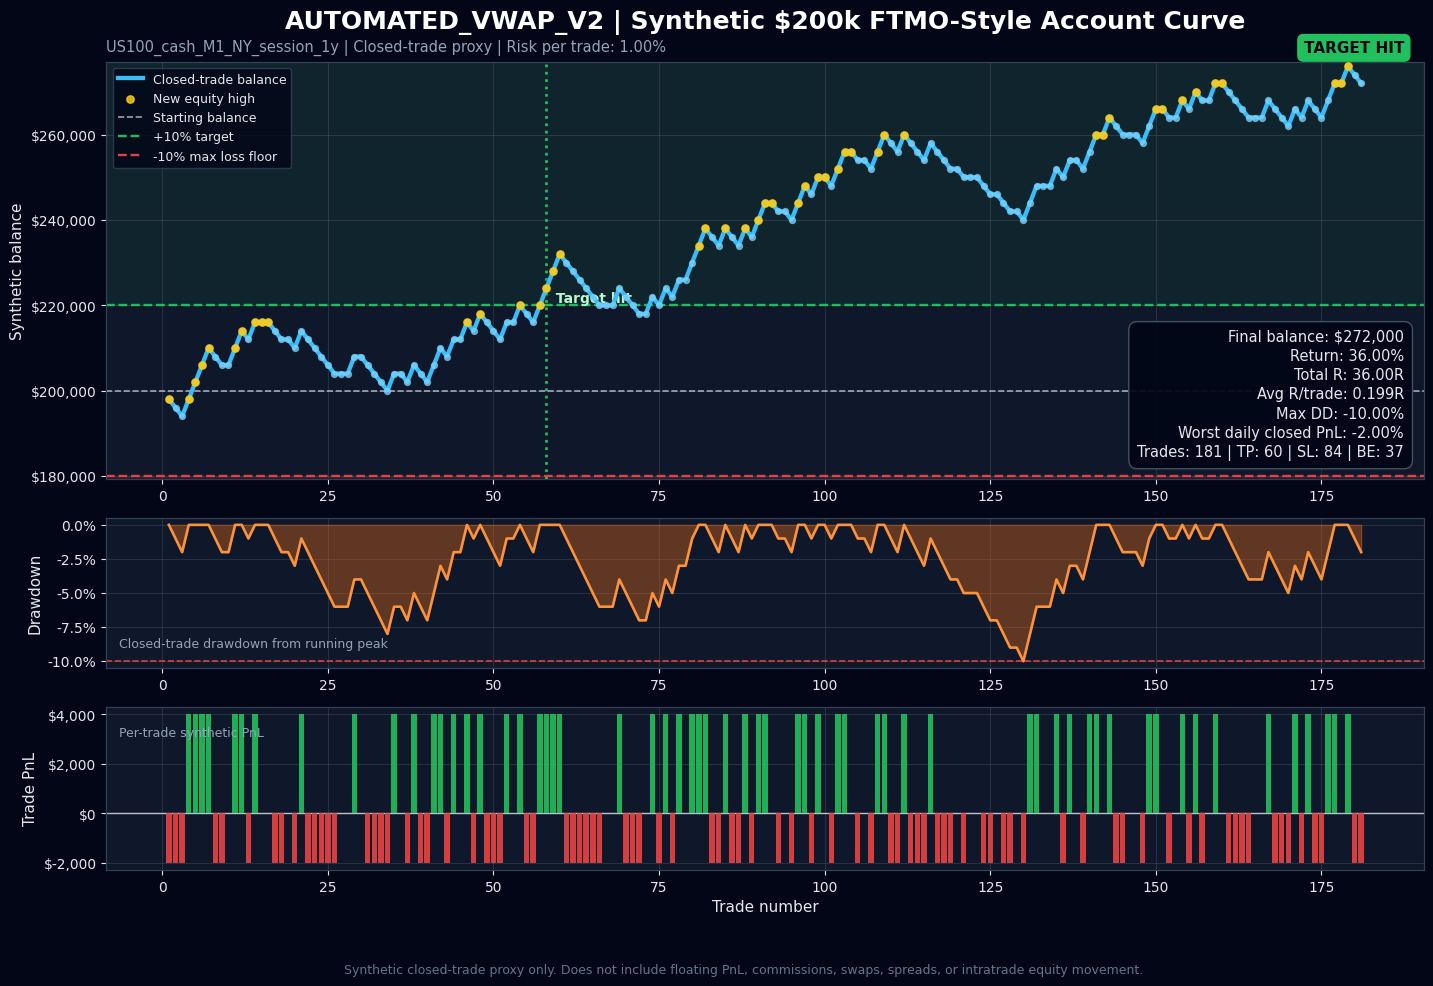

Saved synthetic FTMO-style chart: artifacts\report_charts\automated_vwap_v2__US100_cash_M1_NY_session_1y__ftmo_200k_synthetic_equity.png


In [48]:
# ------------------------------------------------------------------
# Synthetic FTMO-style $200k account report chart
# ------------------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ------------------------------------------------------------------
# Report chart dataset selector
# ------------------------------------------------------------------
# Choose which configured comparison dataset gets the flashy FTMO-style chart.
#
# Option 1: select by exact dataset name
# Option 2: select by row/index from CONFIG["comparison_datasets"]
#
# For your current table:
# 0 = US100_cash_M1_NY_session_30d
# 1 = US100_cash_M1_NY_session_1y

REPORT_CHART_DATASET_NAME = "US100_cash_M1_NY_session_1y"
REPORT_CHART_DATASET_INDEX = None


FTMO_SYNTHETIC_CONFIG = {
    "initial_balance": 200_000.0,
    "profit_target_pct": 10.0,
    "max_loss_pct": 10.0,
    "chart_dpi": 240,
}


def select_report_chart_dataset_config(
    config: dict,
    dataset_name: str | None = None,
    dataset_index: int | None = None,
) -> dict:
    """
    Select one dataset from CONFIG['comparison_datasets'] for the report chart.
    """
    comparison_datasets = config["comparison_datasets"]

    if dataset_index is not None:
        return comparison_datasets[int(dataset_index)]

    if dataset_name is not None:
        matches = [
            dataset_config
            for dataset_config in comparison_datasets
            if dataset_config.get("dataset_name") == dataset_name
        ]

        if len(matches) == 0:
            available_names = [
                dataset_config.get("dataset_name")
                for dataset_config in comparison_datasets
            ]

            raise ValueError(
                f"No dataset matched REPORT_CHART_DATASET_NAME={dataset_name!r}.\n"
                f"Available datasets: {available_names}"
            )

        return matches[0]

    return comparison_datasets[-1]


def safe_report_filename_part(value: str) -> str:
    """
    Safe filename helper for report chart exports.
    """
    return (
        str(value)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
        .replace("__", "_")
    )


def run_active_strategy_details_for_dataset(base_config: dict, dataset_config: dict) -> dict:
    """
    Run the active notebook strategy on the selected dataset and return the full trade log.

    This version does not depend on run_v1/v2/v3_backtest_details_for_dataset being loaded.
    It directly uses the same core pipeline already used by the notebook comparison table.
    """
    run_config = base_config.copy()
    run_config.update(dataset_config)

    raw_df_local, data_file_local = load_market_data(run_config)

    engine_df_local = build_existing_engine_output(raw_df_local, ENGINE_CONFIG)
    automation_df_local = prepare_automation_dataframe(engine_df_local)
    features_df_local = add_automation_features(automation_df_local, run_config)
    signals_df_local = add_v1_green_signals(features_df_local, run_config)

    trades_df_local, daily_summary_df_local, skipped_execution_signals_df_local = (
        run_v1_trade_simulation_with_daily_controls(
            signals_df_local,
            run_config,
        )
    )

    return {
        "config": run_config,
        "dataset_name": run_config["dataset_name"],
        "trades_df": trades_df_local,
        "daily_summary_df": daily_summary_df_local,
        "data_file": data_file_local,
    }


def build_synthetic_account_curve(
    trades: pd.DataFrame,
    config: dict,
    synthetic_config: dict,
) -> pd.DataFrame:
    """
    Build a closed-trade synthetic $200k account curve.

    This is a synthetic reporting curve, not an official prop-firm rule engine.
    """
    if trades is None or len(trades) == 0:
        return pd.DataFrame()

    curve = trades.sort_values("entry_time").reset_index(drop=True).copy()

    initial_balance = float(synthetic_config["initial_balance"])

    curve["trade_number"] = np.arange(1, len(curve) + 1)

    if "account_pct" in curve.columns:
        curve["trade_account_pct"] = curve["account_pct"].astype(float)
    else:
        curve["trade_account_pct"] = (
            curve["r_multiple"].astype(float) * float(config["risk_per_trade_pct"])
        )

    curve["trade_pnl_usd"] = initial_balance * curve["trade_account_pct"] / 100.0

    curve["balance_before_trade"] = (
        initial_balance + curve["trade_pnl_usd"].cumsum().shift(fill_value=0.0)
    )
    curve["balance_after_trade"] = initial_balance + curve["trade_pnl_usd"].cumsum()

    curve["return_pct"] = 100.0 * (
        curve["balance_after_trade"] / initial_balance - 1.0
    )

    curve["running_peak_balance"] = curve["balance_after_trade"].cummax()
    curve["drawdown_usd"] = (
        curve["balance_after_trade"] - curve["running_peak_balance"]
    )
    curve["drawdown_pct_initial"] = (
        100.0 * curve["drawdown_usd"] / initial_balance
    )

    if "session_date" in curve.columns:
        curve["session_date"] = pd.to_datetime(curve["session_date"]).dt.date
    else:
        curve["session_date"] = pd.to_datetime(curve["exit_time"]).dt.date

    curve["daily_closed_pnl_usd"] = curve.groupby("session_date")[
        "trade_pnl_usd"
    ].cumsum()
    curve["daily_closed_pnl_pct_initial"] = (
        100.0 * curve["daily_closed_pnl_usd"] / initial_balance
    )

    curve["is_new_equity_high"] = (
        curve["balance_after_trade"] >= curve["balance_after_trade"].cummax()
    )

    curve["strategy_version"] = config["strategy_version"]
    curve["dataset_name"] = config["dataset_name"]

    return curve


def usd_formatter(value, _):
    return f"${value:,.0f}"


def pct_formatter(value, _):
    return f"{value:.1f}%"


def plot_synthetic_ftmo_account_curve(
    account_curve: pd.DataFrame,
    config: dict,
    synthetic_config: dict,
    report_charts_dir: Path,
) -> Path | None:
    """
    Save a polished synthetic FTMO-style account chart for GitHub.
    """
    if account_curve is None or len(account_curve) == 0:
        print("No trades available, so no synthetic account chart was created.")
        return None

    report_charts_dir.mkdir(parents=True, exist_ok=True)

    initial_balance = float(synthetic_config["initial_balance"])
    profit_target_pct = float(synthetic_config["profit_target_pct"])
    max_loss_pct = float(synthetic_config["max_loss_pct"])

    profit_target_balance = initial_balance * (1.0 + profit_target_pct / 100.0)
    max_loss_floor = initial_balance * (1.0 - max_loss_pct / 100.0)

    final_balance = float(account_curve["balance_after_trade"].iloc[-1])
    final_return_pct = 100.0 * (final_balance / initial_balance - 1.0)

    max_balance = float(account_curve["balance_after_trade"].max())
    min_balance = float(account_curve["balance_after_trade"].min())

    max_drawdown_pct = float(account_curve["drawdown_pct_initial"].min())
    worst_daily_closed_pnl_pct = float(
        account_curve["daily_closed_pnl_pct_initial"].min()
    )

    total_r = float(account_curve["r_multiple"].sum())
    average_r = float(account_curve["r_multiple"].mean())

    tp_count = int((account_curve["result"] == "TP").sum())
    sl_count = int((account_curve["result"] == "SL").sum())
    be_count = int((account_curve["result"] == "BE").sum())

    hit_profit_target = bool(
        (account_curve["balance_after_trade"] >= profit_target_balance).any()
    )
    hit_max_loss = bool(
        (account_curve["balance_after_trade"] <= max_loss_floor).any()
    )

    if hit_max_loss:
        status = "MAX LOSS HIT"
        badge_colour = "#ef4444"
    elif hit_profit_target:
        status = "TARGET HIT"
        badge_colour = "#22c55e"
    else:
        status = "TARGET NOT HIT"
        badge_colour = "#f59e0b"

    safe_strategy = safe_report_filename_part(config["strategy_version"])
    safe_dataset = safe_report_filename_part(config["dataset_name"])

    chart_path = (
        report_charts_dir
        / f"{safe_strategy}__{safe_dataset}__ftmo_200k_synthetic_equity.png"
    )

    x = account_curve["trade_number"].to_numpy()
    balance = account_curve["balance_after_trade"].astype(float).to_numpy()
    drawdown = account_curve["drawdown_pct_initial"].astype(float).to_numpy()
    pnl = account_curve["trade_pnl_usd"].astype(float).to_numpy()

    bar_colours = np.where(pnl >= 0, "#22c55e", "#ef4444")

    fig = plt.figure(figsize=(17, 10.5), facecolor="#020617")
    grid = fig.add_gridspec(
        3,
        1,
        height_ratios=[3.2, 1.15, 1.25],
        hspace=0.16,
    )

    ax_equity = fig.add_subplot(grid[0])
    ax_dd = fig.add_subplot(grid[1], sharex=ax_equity)
    ax_pnl = fig.add_subplot(grid[2], sharex=ax_equity)

    for ax in [ax_equity, ax_dd, ax_pnl]:
        ax.set_facecolor("#0f172a")
        ax.grid(True, alpha=0.16, linewidth=0.8)
        ax.tick_params(colors="#e5e7eb", labelsize=10)

        for spine in ax.spines.values():
            spine.set_color("#334155")
            spine.set_linewidth(0.9)

    # ------------------------------------------------------------------
    # Equity panel
    # ------------------------------------------------------------------
    y_top = max(max_balance, profit_target_balance) * 1.004
    y_bottom = min(min_balance, max_loss_floor) * 0.996

    ax_equity.axhspan(
        profit_target_balance,
        y_top,
        color="#22c55e",
        alpha=0.08,
    )

    ax_equity.axhspan(
        y_bottom,
        max_loss_floor,
        color="#ef4444",
        alpha=0.10,
    )

    ax_equity.plot(
        x,
        balance,
        linewidth=3.1,
        color="#38bdf8",
        label="Closed-trade balance",
        zorder=4,
    )

    ax_equity.scatter(
        x,
        balance,
        s=18,
        color="#7dd3fc",
        alpha=0.70,
        zorder=5,
    )

    new_highs = account_curve[account_curve["is_new_equity_high"]].copy()

    if len(new_highs) > 0:
        ax_equity.scatter(
            new_highs["trade_number"],
            new_highs["balance_after_trade"],
            s=28,
            color="#facc15",
            alpha=0.85,
            label="New equity high",
            zorder=6,
        )

    ax_equity.axhline(
        initial_balance,
        color="#cbd5e1",
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label="Starting balance",
    )

    ax_equity.axhline(
        profit_target_balance,
        color="#22c55e",
        linestyle="--",
        linewidth=1.7,
        alpha=0.95,
        label=f"+{profit_target_pct:.0f}% target",
    )

    ax_equity.axhline(
        max_loss_floor,
        color="#ef4444",
        linestyle="--",
        linewidth=1.7,
        alpha=0.95,
        label=f"-{max_loss_pct:.0f}% max loss floor",
    )

    target_hits = account_curve[
        account_curve["balance_after_trade"] >= profit_target_balance
    ]

    if len(target_hits) > 0:
        first_target_trade = int(target_hits["trade_number"].iloc[0])

        ax_equity.axvline(
            first_target_trade,
            color="#22c55e",
            linestyle=":",
            linewidth=2.0,
            alpha=0.95,
            zorder=3,
        )

        ax_equity.text(
            first_target_trade,
            profit_target_balance,
            "  Target hit",
            color="#bbf7d0",
            fontsize=10,
            fontweight="bold",
            va="bottom",
            ha="left",
        )

    loss_hits = account_curve[
        account_curve["balance_after_trade"] <= max_loss_floor
    ]

    if len(loss_hits) > 0:
        first_loss_trade = int(loss_hits["trade_number"].iloc[0])

        ax_equity.axvline(
            first_loss_trade,
            color="#ef4444",
            linestyle=":",
            linewidth=2.0,
            alpha=0.95,
            zorder=3,
        )

        ax_equity.text(
            first_loss_trade,
            max_loss_floor,
            "  Max loss hit",
            color="#fecaca",
            fontsize=10,
            fontweight="bold",
            va="top",
            ha="left",
        )

    ax_equity.set_ylim(y_bottom, y_top)
    ax_equity.yaxis.set_major_formatter(FuncFormatter(usd_formatter))
    ax_equity.set_ylabel("Synthetic balance", color="#e5e7eb", fontsize=11)

    title = (
        f"{config['strategy_version'].upper()} | "
        f"Synthetic $200k FTMO-Style Account Curve"
    )

    subtitle = (
        f"{config['dataset_name']} | "
        f"Closed-trade proxy | "
        f"Risk per trade: {config['risk_per_trade_pct']:.2f}%"
    )

    ax_equity.set_title(
        title,
        color="white",
        fontsize=18,
        fontweight="bold",
        pad=24,
    )

    ax_equity.text(
        0.0,
        1.015,
        subtitle,
        transform=ax_equity.transAxes,
        ha="left",
        va="bottom",
        fontsize=10.5,
        color="#94a3b8",
    )

    ax_equity.text(
        0.985,
        1.015,
        status,
        transform=ax_equity.transAxes,
        ha="right",
        va="bottom",
        fontsize=11,
        color="#020617",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.38",
            facecolor=badge_colour,
            edgecolor=badge_colour,
            alpha=0.98,
        ),
    )

    stats_text = (
        f"Final balance: ${final_balance:,.0f}\n"
        f"Return: {final_return_pct:.2f}%\n"
        f"Total R: {total_r:.2f}R\n"
        f"Avg R/trade: {average_r:.3f}R\n"
        f"Max DD: {max_drawdown_pct:.2f}%\n"
        f"Worst daily closed PnL: {worst_daily_closed_pnl_pct:.2f}%\n"
        f"Trades: {len(account_curve)} | TP: {tp_count} | SL: {sl_count} | BE: {be_count}"
    )

    ax_equity.text(
        0.985,
        0.045,
        stats_text,
        transform=ax_equity.transAxes,
        ha="right",
        va="bottom",
        fontsize=10.5,
        color="#e5e7eb",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.58",
            facecolor="#020617",
            edgecolor="#475569",
            alpha=0.94,
        ),
    )

    ax_equity.legend(
        loc="upper left",
        frameon=True,
        facecolor="#020617",
        edgecolor="#334155",
        labelcolor="#e5e7eb",
        fontsize=9,
    )

    # ------------------------------------------------------------------
    # Drawdown panel
    # ------------------------------------------------------------------
    ax_dd.fill_between(
        x,
        drawdown,
        0,
        color="#f97316",
        alpha=0.35,
        zorder=2,
    )

    ax_dd.plot(
        x,
        drawdown,
        color="#fb923c",
        linewidth=1.9,
        zorder=3,
    )

    ax_dd.axhline(
        -max_loss_pct,
        color="#ef4444",
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    ax_dd.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax_dd.set_ylabel("Drawdown", color="#e5e7eb", fontsize=11)

    ax_dd.text(
        0.01,
        0.12,
        "Closed-trade drawdown from running peak",
        transform=ax_dd.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        color="#94a3b8",
    )

    # ------------------------------------------------------------------
    # Trade PnL panel
    # ------------------------------------------------------------------
    ax_pnl.bar(
        x,
        pnl,
        color=bar_colours,
        alpha=0.88,
        width=0.82,
        zorder=3,
    )

    ax_pnl.axhline(
        0,
        color="#e5e7eb",
        linewidth=1.0,
        alpha=0.8,
    )

    ax_pnl.yaxis.set_major_formatter(FuncFormatter(usd_formatter))
    ax_pnl.set_ylabel("Trade PnL", color="#e5e7eb", fontsize=11)
    ax_pnl.set_xlabel("Trade number", color="#e5e7eb", fontsize=11)

    ax_pnl.text(
        0.01,
        0.88,
        "Per-trade synthetic PnL",
        transform=ax_pnl.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="#94a3b8",
    )

    fig.text(
        0.5,
        0.012,
        (
            "Synthetic closed-trade proxy only. "
            "Does not include floating PnL, commissions, swaps, spreads, "
            "or intratrade equity movement."
        ),
        ha="center",
        color="#64748b",
        fontsize=9,
    )

    fig.savefig(
        chart_path,
        dpi=int(synthetic_config["chart_dpi"]),
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )

    plt.show()

    print(f"Saved synthetic FTMO-style chart: {chart_path.relative_to(PROJECT_ROOT)}")

    return chart_path


REPORT_DATASET_CONFIG = select_report_chart_dataset_config(
    config=CONFIG,
    dataset_name=REPORT_CHART_DATASET_NAME,
    dataset_index=REPORT_CHART_DATASET_INDEX,
)

print("Running synthetic FTMO-style chart for:")
print(REPORT_DATASET_CONFIG)

report_backtest = run_active_strategy_details_for_dataset(
    base_config=CONFIG,
    dataset_config=REPORT_DATASET_CONFIG,
)

synthetic_account_curve_df = build_synthetic_account_curve(
    trades=report_backtest["trades_df"],
    config=report_backtest["config"],
    synthetic_config=FTMO_SYNTHETIC_CONFIG,
)

synthetic_ftmo_chart_path = plot_synthetic_ftmo_account_curve(
    account_curve=synthetic_account_curve_df,
    config=report_backtest["config"],
    synthetic_config=FTMO_SYNTHETIC_CONFIG,
    report_charts_dir=ARTIFACTS_DIR / "report_charts",
)

## Risk Diagnostics

This section checks losing streaks, no-TP runs, and max drawdown in R for each V2 comparison dataset.

The diagnostics use the active V2 strategy configuration.

In [46]:
# Active V2 risk diagnostic: max no-win run and max drawdown for each comparison dataset

def run_v2_backtest_details_for_dataset(base_config: dict, dataset_config: dict) -> dict:
    run_config = base_config.copy()
    run_config.update(dataset_config)

    raw_df, data_file = load_market_data(run_config)

    engine_df_local = build_existing_engine_output(raw_df, ENGINE_CONFIG)
    automation_df_local = prepare_automation_dataframe(engine_df_local)
    features_df_local = add_automation_features(automation_df_local, run_config)
    signals_df_local = add_v1_green_signals(features_df_local, run_config)

    skipped_generation_df_local = signals_df_local[
        (signals_df_local["raw_signal_name"] != "NO_SIGNAL")
        & (signals_df_local["v1_signal_name"] == "NO_SIGNAL")
    ].copy()

    trades_df_local, daily_summary_df_local, skipped_execution_df_local = run_v1_trade_simulation_with_daily_controls(
        signals_df_local,
        run_config,
    )

    return {
        "dataset_name": run_config["dataset_name"],
        "trades_df": trades_df_local,
        "daily_summary_df": daily_summary_df_local,
    }


def calculate_risk_diagnostics(trades: pd.DataFrame) -> dict:
    if trades is None or len(trades) == 0:
        return {
            "Trades": 0,
            "Max Consecutive SL": 0,
            "Worst No-TP Run R": 0.0,
            "Max Equity Drawdown R": 0.0,
        }

    trades = trades.sort_values("entry_time").reset_index(drop=True).copy()

    max_consecutive_sl = 0
    current_consecutive_sl = 0

    worst_no_tp_run_r = 0.0
    current_no_tp_run_r = 0.0

    equity = 0.0
    peak_equity = 0.0
    max_drawdown = 0.0

    for _, trade in trades.iterrows():
        result = trade["result"]
        r = float(trade["r_multiple"])

        # Pure consecutive SL streak
        if result == "SL":
            current_consecutive_sl += 1
            max_consecutive_sl = max(max_consecutive_sl, current_consecutive_sl)
        else:
            current_consecutive_sl = 0

        # No-TP run: SL and BE keep the no-win run going; TP resets it
        if result == "TP":
            current_no_tp_run_r = 0.0
        else:
            current_no_tp_run_r += r
            worst_no_tp_run_r = min(worst_no_tp_run_r, current_no_tp_run_r)

        # Equity drawdown
        equity += r
        peak_equity = max(peak_equity, equity)
        drawdown = equity - peak_equity
        max_drawdown = min(max_drawdown, drawdown)

    return {
        "Trades": len(trades),
        "Max Consecutive SL": max_consecutive_sl,
        "Worst No-TP Run R": worst_no_tp_run_r,
        "Max Equity Drawdown R": max_drawdown,
    }


risk_rows = []

for dataset_config in CONFIG["comparison_datasets"]:
    details = run_v2_backtest_details_for_dataset(CONFIG, dataset_config)
    diagnostics = calculate_risk_diagnostics(details["trades_df"])

    risk_rows.append(
        {
            "Dataset": details["dataset_name"],
            **diagnostics,
            "Worst No-TP Run %": f"{diagnostics['Worst No-TP Run R']:.2f}%",
            "Max Drawdown %": f"{diagnostics['Max Equity Drawdown R']:.2f}%",
        }
    )

risk_diagnostics_table = pd.DataFrame(risk_rows)
risk_diagnostics_table

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
All required engine output columns are available.
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.


,Dataset,Trades,Max Consecutive SL,Worst No-TP Run R,Max Equity Drawdown R,Worst No-TP Run %,Max Drawdown %
0,US100_cash_M1_NY_session_30d,21,2,-3.0,-3.0,-3.00%,-3.00%
1,US100_cash_M1_NY_session_1y,181,6,-9.0,-10.0,-9.00%,-10.00%
